In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
import pandas as pd

import numpy as np
from tqdm.auto import tqdm
    
sys.path.insert(1, "../../")

import precision_mapping as pm
import CAP_tools

sys.path.insert(1, "../../network_control")
import surface_mapping as sfm

# HCP PM Pipeline 

### Parameters

In [2]:
overwrite = False

exclude_subcortex = True
mask = False
sparsity = 0.1

silent = True

pm.utils.printer.silent = silent

### paths

In [3]:
results_dir = "/data/data7/network_control/results/HCP_7T_analysis/precision_maps/rfMRI_REST_7T_ALL"
dtseries_list_txt = "/data/data7/network_control/scripts/_params/HCP_7T_CAP_analysis/HCP_7T_CAP_analysis_rfMRI_REST_7T_ALL_dtseries_list.txt"

with open(dtseries_list_txt) as file:
    dtseries_paths = file.read().strip().split()

cached_dtseries_paths = pm.utils.cache_tmp_path(dtseries_paths, write_cache=False)

subjects = [path.split("/MNINon")[0].split("/")[-1] for path in dtseries_paths]

voxel_FC_file_ending = "voxel_FC.npz"
parcel_file_ending = "parcellation.npy"
network_file_ending = "networks.npy"

Caching paths in ~/_tmp:   0%|          | 0/177 [00:00<?, ?it/s]

# TODO: Correlations are fixed, now add other steps in pipelines

In [4]:
# for max_trs in [300, 600, 1200, 2400]:
for max_trs in [None, 300, 1200, 2400, 3300]:
# for max_trs in [300, 1200, 2400, None]:
# for max_trs in [None]:
    generic_save_paths = []
    for subject in subjects:
        label_tag = pm.utils.create_path_tag(subject, sparsity, mask, exclude_subcortex, max_trs=max_trs)
        generic_save_paths.append(f"{results_dir}/{subject}/{label_tag}_{{file_ending}}")
        # print()
        os.makedirs(f"{results_dir}/{subject}", exist_ok=True)

    voxel_FC_save_paths = [path.format(file_ending=voxel_FC_file_ending) for path in generic_save_paths]
    parcel_save_paths = [path.format(file_ending=parcel_file_ending) for path in generic_save_paths]
    network_save_paths = [path.format(file_ending=network_file_ending) for path in generic_save_paths]

# TODO:

- Create network assignment files (one based on FC + spatial, one just spatial, probably dlabels or npy, also save network assignment weights)

# Assignment FC Analysis

In [5]:
import scipy
import numpy as np
import nibabel as nb

import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
import glob

In [7]:
vfc_paths = glob.glob("/data/data7/network_control/results/HCP_analysis/precision_maps/rfMRI_REST_7T_ALL/102311/102311*_voxel_FC.npz")
for vfc_path in vfc_paths:
    print(vfc_path)
    vfc_i = scipy.sparse.load_npz(vfc_path)
    print(vfc_i.data.shape, np.max(vfc_i), np.mean(vfc_i), np.min(vfc_i))
    print(vfc_i.__repr__())
    # break

# Size Stability Metrics

In [8]:
priors_path = "../../precision_mapping/resources/priors.mat"

priors = scipy.io.loadmat(priors_path)
FC, spatial, network_labels, _ = priors["Priors"][0, 0]
network_labels = np.array([lab[0][0] for lab in network_labels])
FC, spatial = FC.T, spatial.T

In [9]:
example_cifti = nb.load(cached_dtseries_paths[0])

In [10]:
medial_wall_mask_values = CAP_tools.utils.cifti_map(None, np.ones(59412), example_cifti)
medial_wall_mask_L = np.isnan(medial_wall_mask_values["left"])
medial_wall_mask_R = np.isnan(medial_wall_mask_values["right"])
medial_wall_mask_64k = np.hstack([medial_wall_mask_L, medial_wall_mask_R])

Text(0.5, 1.0, 'Mean Vertex Surface Area')

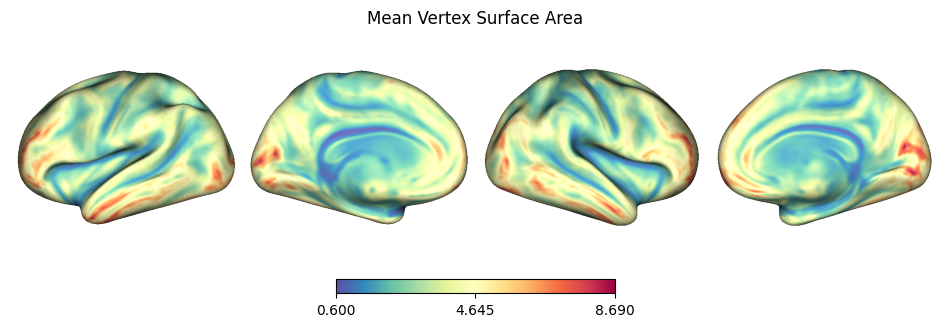

In [11]:
generic_area_file = "/data/data4/earlycort_7114/*/MNINonLinear/fsaverage_LR32k/*.{side}.midthickness.32k_fs_LR.area.func.gii"

all_L_area_files = glob.glob(generic_area_file.format(side="L"))
all_R_area_files = glob.glob(generic_area_file.format(side="R"))

L_SA_all_32k = np.expand_dims(np.array([nb.load(sf).darrays[0].data for sf in all_L_area_files]), -1)
R_SA_all_32k = np.expand_dims(np.array([nb.load(sf).darrays[0].data for sf in all_R_area_files]), -1)
SA_all_64k = np.concat([L_SA_all_32k, R_SA_all_32k], axis=1)
SA_all_cortex = SA_all_64k[:, ~medial_wall_mask_64k]
mean_SA_cortex = np.mean(SA_all_cortex, axis=0)

mean_L_SA = np.mean(L_SA_all_32k, axis=0)[:, 0]
mean_R_SA = np.mean(R_SA_all_32k, axis=0)[:, 0]

mean_SA_values = {"left": mean_L_SA, "right": mean_R_SA}
fig, ax = plt.subplots(figsize=(12, 4))
ax, _ = sfm.surface_plot(mean_SA_values, cmap=plt.cm.Spectral_r, ax=ax)
ax.set_title("Mean Vertex Surface Area")

In [15]:
vni_s, vns_s = [], []
tr_label_s = []
for max_trs in tqdm([300, 1200, 2400, 3300, None]):
    generic_save_paths = []
    for subject in tqdm(subjects, leave=False):
        label_tag = pm.utils.create_path_tag(subject, sparsity, mask, exclude_subcortex, max_trs=max_trs)
        generic_save_paths.append(f"{results_dir}/{subject}/{label_tag}_{{file_ending}}")
    
    
    voxel_FC_save_paths = [path.format(file_ending=voxel_FC_file_ending) for path in generic_save_paths]
    parcel_save_paths = [path.format(file_ending=parcel_file_ending) for path in generic_save_paths]
    network_save_paths = [path.format(file_ending=network_file_ending) for path in generic_save_paths]

    cached_network_save_paths = pm.utils.cache_tmp_path(network_save_paths, write_cache=True)
    
    for network_path in tqdm(cached_network_save_paths):
        vni, vns = np.load(network_path)
        vns_s.append(vns)
        vni_s.append(vni)
        tr_label_s.append(max_trs)

vns_s = np.array(vns_s)
vni_s = np.array(vni_s).astype(int)
tr_label_s = np.array(tr_label_s)
tr_label_s = np.array([i if i else 3600 for i in tr_label_s])

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/177 [00:00<?, ?it/s]

Caching paths in ~/_tmp:   0%|          | 0/177 [00:00<?, ?it/s]

  0%|          | 0/177 [00:00<?, ?it/s]

  0%|          | 0/177 [00:00<?, ?it/s]

...

Caching paths in ~/_tmp:   0%|          | 0/177 [00:00<?, ?it/s]

  0%|          | 0/177 [00:00<?, ?it/s]

  0%|          | 0/177 [00:00<?, ?it/s]

Caching paths in ~/_tmp:   0%|          | 0/177 [00:00<?, ?it/s]

  0%|          | 0/177 [00:00<?, ?it/s]

In [16]:
vert_counts = np.array([(vns_s == net).mean(axis=1) for net in tqdm(network_labels, leave=False)]).T

  0%|          | 0/21 [00:00<?, ?it/s]

In [17]:
def percent_clip(arr, lower=None, upper=None):
    v = arr[~np.isnan(arr)]
    return np.clip(arr, np.percentile(v, lower or 0), np.percentile(v, upper or 100))

def vertex_plot(values, template_cifti, ax=None, pclip=(None, None), **kwargs):
    """ """
    values = percent_clip(values, *pclip)
    values = CAP_tools.utils.cifti_map(None, values, template_cifti)
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 4))
    return sfm.surface_plot(values, ax=ax, **kwargs)

In [18]:
subject_s_big = np.tile(subjects, (len(np.unique(tr_label_s))))

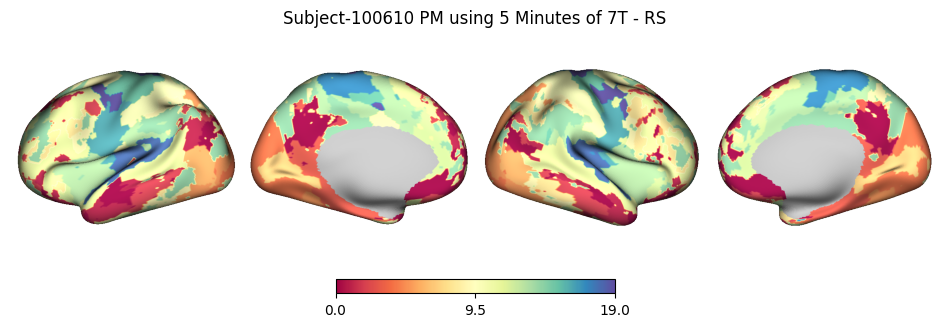

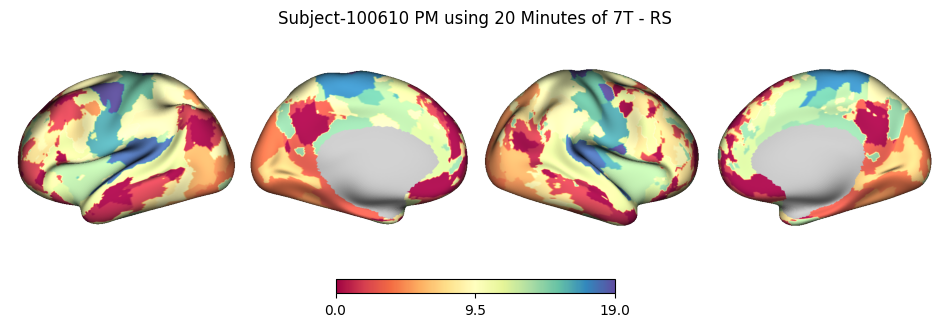

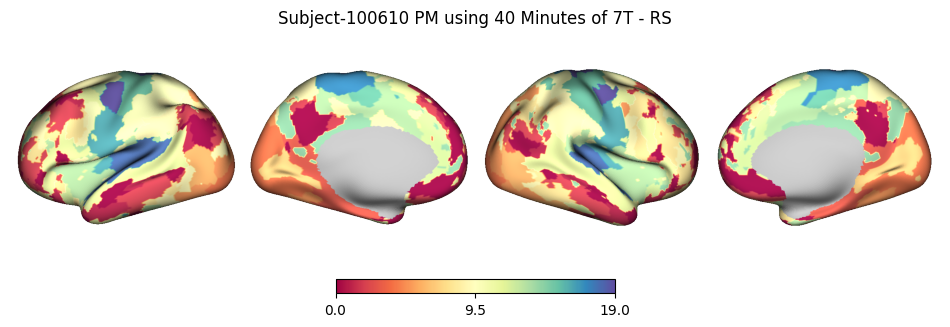

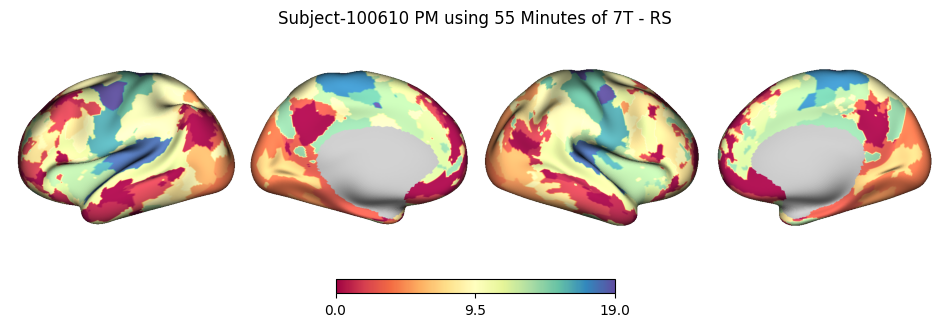

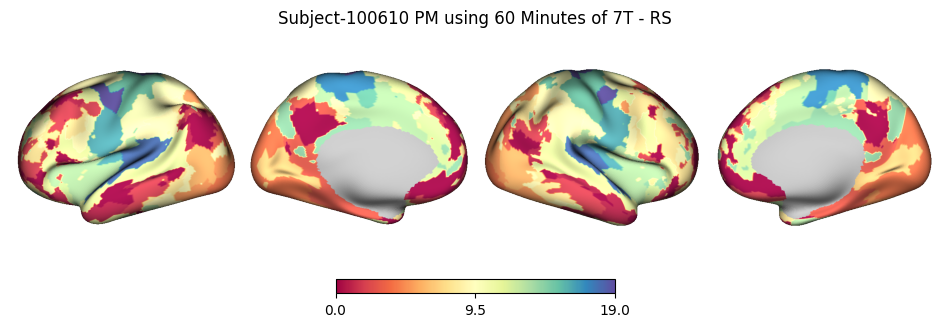

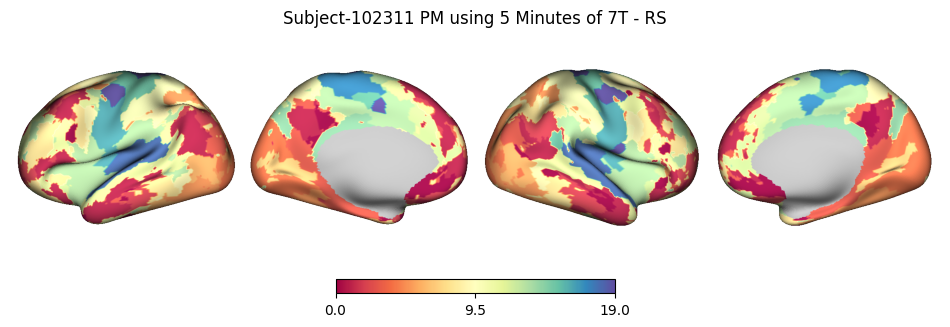

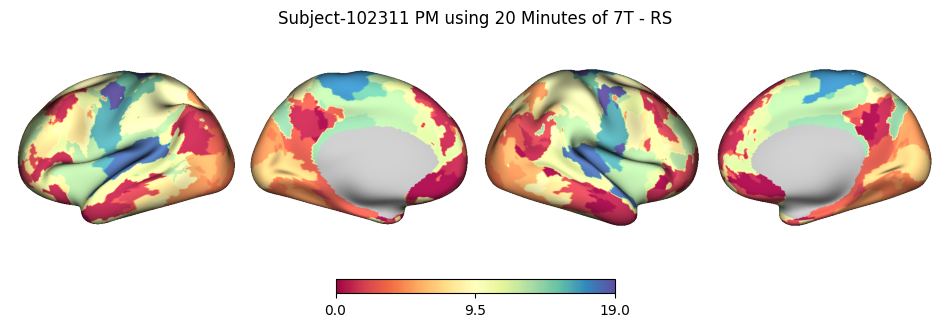

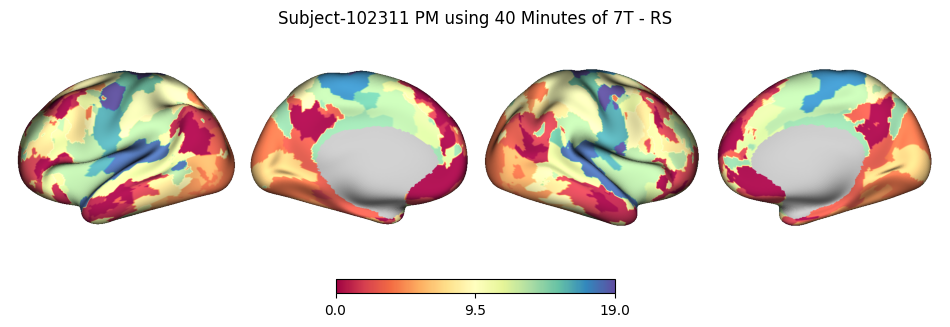

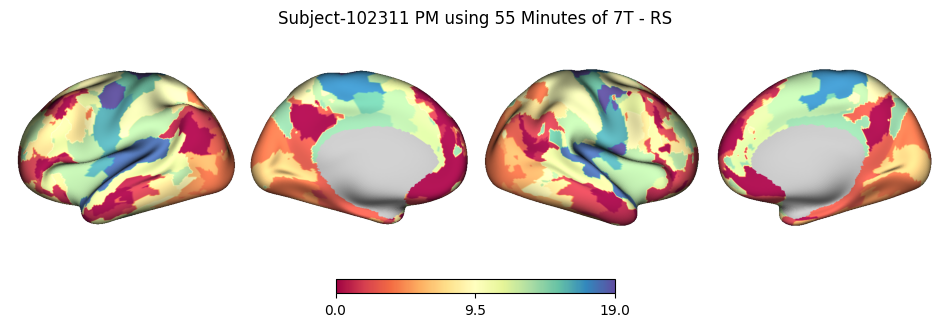

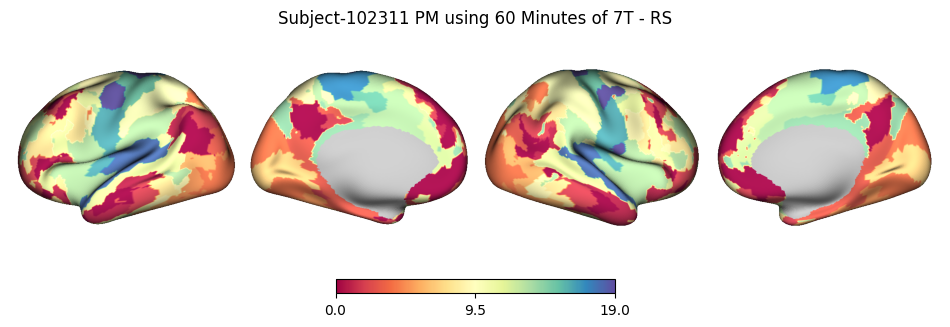

In [20]:
for subject in subjects[:2]:
    sid = subject_s_big == subject
    
    vni_subject_set = vni_s[sid]
    tr_subject_set = tr_label_s[sid]
    
    for vni_subject_tr, tr_subject in zip(vni_subject_set, tr_subject_set):
        ax, _ = vertex_plot(vni_subject_tr, example_cifti, cmap=plt.cm.Spectral)
        ax.set_title(f"Subject-{subject} PM using {tr_subject/60:0.0f} Minutes of 7T - RS")

# Dice Stability over Time

In [21]:
def dice_coef(s1, s2):
    """ """
    assert s1.dtype == s2.dtype

    if not s1.dtype == bool:
        return np.mean([dice_coef(s1 == value, s2 == value) for value in np.unique(np.hstack([s1, s2]))])

    card_sum = np.nansum(s1) + np.nansum(s2)
    assert card_sum > 0
    
    return 2 * np.nansum(s1 * s2) / card_sum

In [22]:
network_dice_s = []
for subject in tqdm(subjects):
    sid = subject_s_big == subject
    network_dice_s.append([dice_coef(vni_tr, vni_s[sid][-1]) for vni_tr in vni_s[sid]])
network_dice_s = np.array(network_dice_s)

  0%|          | 0/177 [00:00<?, ?it/s]

In [23]:
net_spec_dices = {i: [] for i in range(20)}

for subject in tqdm(subjects):
    sid = subject_s_big == subject
    for n in net_spec_dices:
        net_spec_dices[n].append([dice_coef(vni_tr == n, vni_s[sid][-1] == n) for vni_tr in vni_s[sid]])

net_spec_dices = {i: np.array(v) for i, v in net_spec_dices.items()}

  0%|          | 0/177 [00:00<?, ?it/s]

In [24]:
trs = np.sort(np.unique(tr_label_s))

In [25]:
z = np.array([v[:, :-1] for v in net_spec_dices.values()])
trz = (np.tile(trs[:-1], (*z.shape[:-1], 1)) / 60).astype(int)
nz = np.tile(network_labels[:-1], (*z.T.shape[:-1], 1)).T

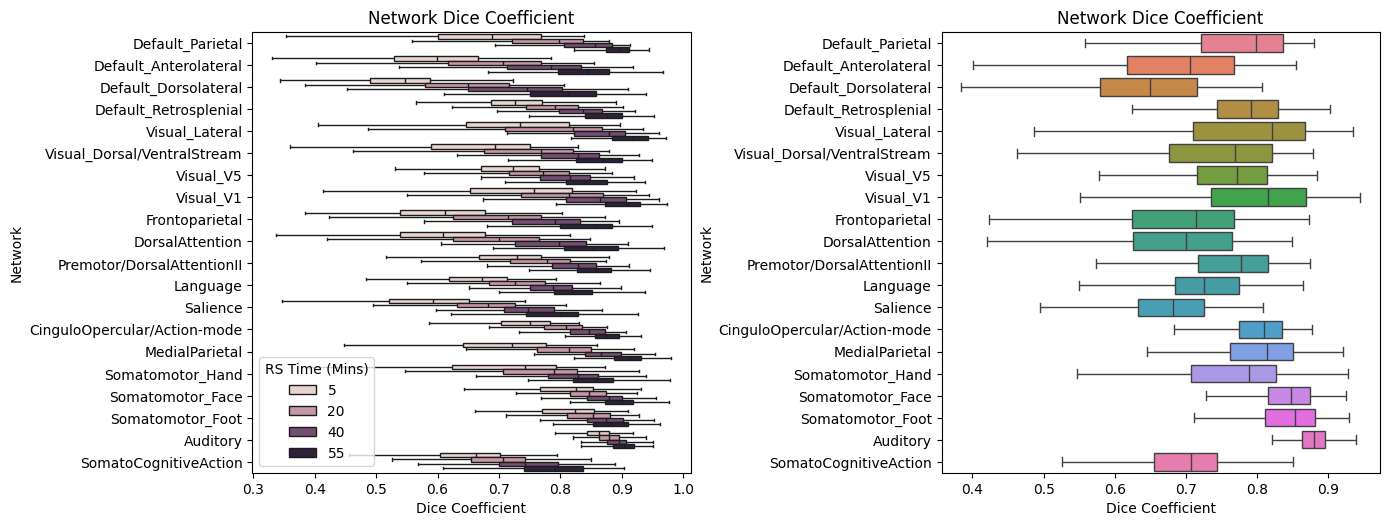

In [26]:
fig, (a0, a1) = plt.subplots(1, 2, figsize=(12, 5))
fig.tight_layout(w_pad=15)
sns.boxplot(y=nz.ravel(), x=z.ravel(), hue=trz.ravel(), showfliers=False, ax=a0)
a0.legend(title="RS Time (Mins)")

x = np.hstack([v[:, 1] for i, v in net_spec_dices.items()])
y=np.tile(network_labels[:-1], (177, 1)).T.ravel()
sns.boxplot(y=y, x=x, hue=y, showfliers=False, ax=a1)
a0.set(xlabel="Dice Coefficient", ylabel="Network", title="Network Dice Coefficient")
a1.set(xlabel="Dice Coefficient", ylabel="Network", title="Network Dice Coefficient");

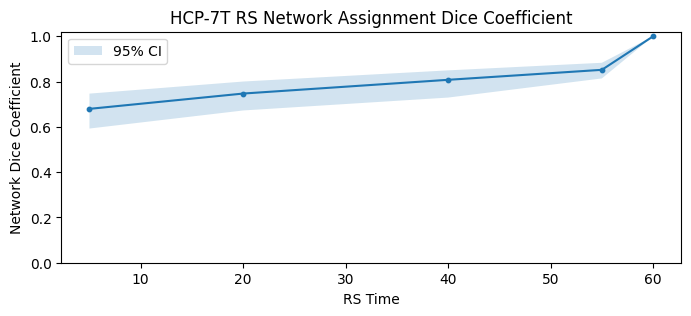

In [27]:
m = np.mean(network_dice_s, axis=0)
low_lim, high_lim = np.percentile(network_dice_s, 2.5, axis=0), np.percentile(network_dice_s, 97.5, axis=0)
times = trs / 60

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(times, m, color="C0")
ax.scatter(times, m, color="C0", s=10)
ax.fill_between(times, low_lim, high_lim, alpha=0.2, label="95% CI")
# ax.axhline(1/20, linestyle="--", color="C3", alpha=1, linewidth=1, label="Random Chance")
ax.set(title="HCP-7T RS Network Assignment Dice Coefficient", xlabel="RS Time", ylabel="Network Dice Coefficient")
ax.set_ylim(0, None)
ax.legend()

(<Axes: >, <surfplot.plotting.Plot at 0x33bbd08d0>)

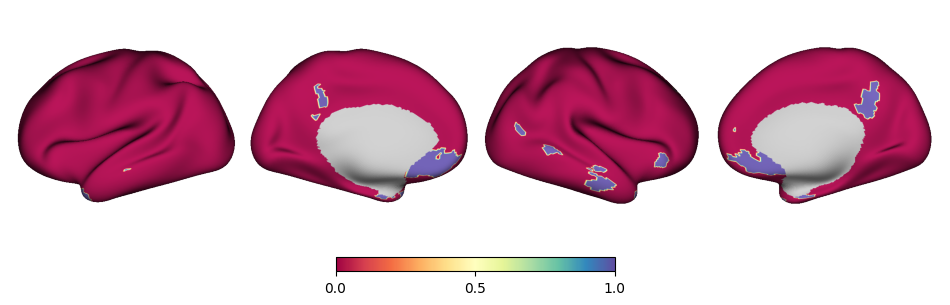

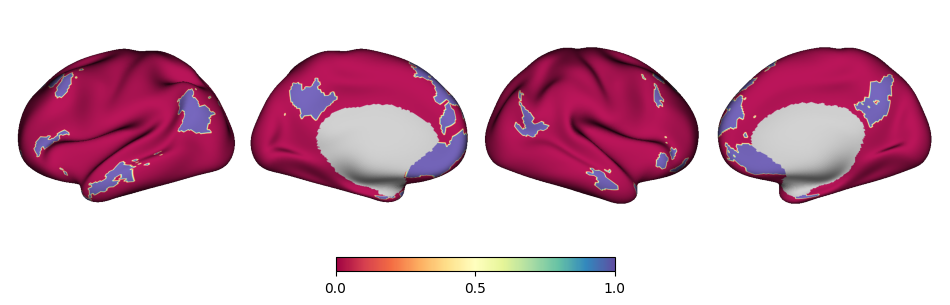

In [28]:
vertex_plot((vni_subject_set[1] == 0) * 1, example_cifti, cmap=plt.cm.Spectral)
vertex_plot((vni_subject_set[2] == 0) * 1, example_cifti, cmap=plt.cm.Spectral)

In [29]:
compare_table = np.arange(np.max(vni_s) + 2).reshape(1, 1, -1)
ni_index_set = np.expand_dims(vni_s, 2) == compare_table
sizes = mean_SA_cortex * ni_index_set
size_frac = sizes / sizes.sum(axis=(1, 2), keepdims=True)
network_sizes = size_frac.sum(axis=1)

In [30]:
EC_vert_size_csv = "/data/data7/network_control/projects/precision_mapping/notebooks/scratch/EC_vert_count_data.csv"
EC_df = pd.read_csv(EC_vert_size_csv)
szp_index = EC_df["subject"].str.contains("_08_").values
EC_df["TR"] = np.array(["HC", "SzP"])[szp_index * 1]

# EC_sizes_csv = "/data/data7/network_control/projects/voxel_analysis/notebooks/scratch/EC_sizes_data.csv"
# EC_df = pd.read_csv(EC_sizes_csv)
# szp_index = EC_df["subject"].str.contains("_08_").values
# EC_df["TR"] = np.array(["HC", "SzP"])[szp_index * 1]

In [31]:
df = pd.DataFrame(vert_counts, columns=network_labels)
# df = pd.DataFrame(network_sizes, columns=network_labels)
df["subject"] = np.tile(subjects, (len(np.unique(tr_label_s))))
df["TR"] = tr_label_s

# df = pd.concat([df, EC_df])
mdf = pd.melt(df, id_vars=["subject", "TR"], var_name="network", value_name="n_vertices")

<Axes: xlabel='n_vertices', ylabel='network'>

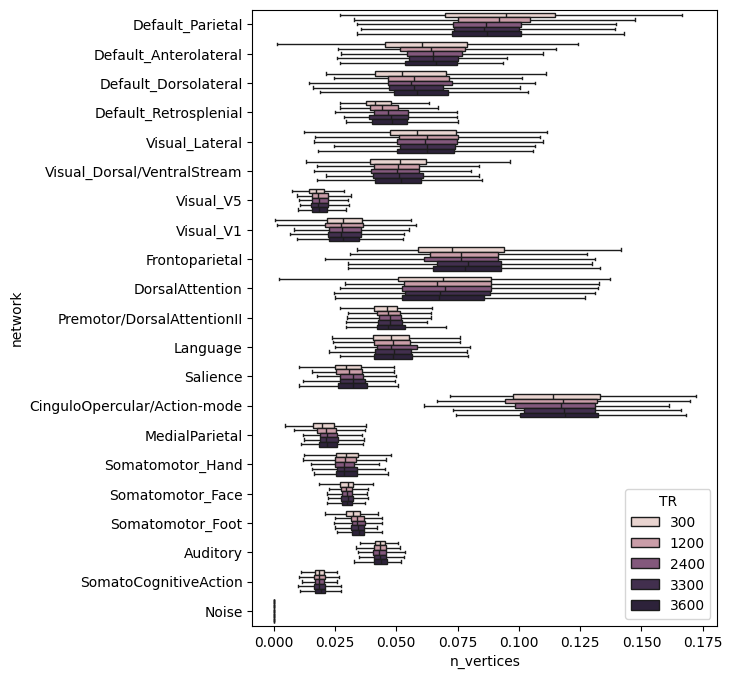

In [32]:
fig, ax = plt.subplots(figsize=(6, 8))
sns.boxplot(data=mdf, y="network", x="n_vertices", hue="TR", showfliers=False, ax=ax)
# sns.boxplot(data=mdf, y="network", x="n_vertices", hue="TR", showfliers=False, ax=ax)

In [33]:
hcp_1200 = df.query("TR == 1200")
szp_df = df.query("TR == 'SzP'")
hc_df = df.query("TR == 'HC'")

hcp_df = df.loc[df["TR"].apply(lambda s: isinstance(s, int))]

In [34]:
t_s, p_s = scipy.stats.ttest_ind(hcp_1200[network_labels], hc_df[network_labels])

for n, t, p in zip(network_labels, t_s, p_s):
    if p < 0.05:
        print(f"{n}:: {t:0.2f} {p:0.5f}")

/var/folders/p0/zng86kys7t3578bm_dw7qjym00014h/T/ipykernel_3174/55583869.py:1: SmallSampleWarning: All axis-slices of one or more sample arguments are too small; all elements of returned arrays will be NaN. See documentation for sample size requirements.
  t_s, p_s = scipy.stats.ttest_ind(hcp_1200[network_labels], hc_df[network_labels])


In [35]:
mtr_df = pd.melt(df[network_labels].groupby(df["TR"]).std().reset_index(), id_vars=["TR"], var_name="network", value_name="std")

In [36]:
size_corrs = []
lang_size_frac_diff_s = []
lang_sizes_s = []
for subject, subj_df in hcp_df.groupby("subject"):
    z = subj_df.sort_values("TR").drop("subject", axis=1).set_index("TR").T.corr()[3600]
    trs = z.index.values
    size_corrs.append(z.values)
    
    lang_sizes = subj_df.sort_values("TR").set_index("TR")["Language"]
    lang_sizes_s.append(lang_sizes)
    lang_size_frac_diff_s.append((lang_sizes.values[-1] - lang_sizes.values) / lang_sizes.values[-1])

size_corrs = np.array(size_corrs) ** 2
trs = trs.astype(int)
lang_size_frac_diff_s = np.array(lang_size_frac_diff_s)

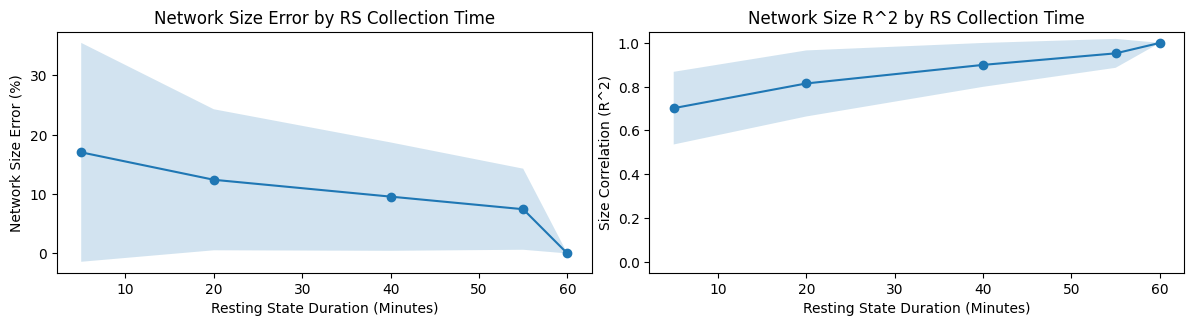

In [53]:
values = lang_size_frac_diff_s * 100

m = np.mean(np.abs(values), axis=0)
s = np.std(np.abs(values), axis=0)
times = trs / 60

fig, (ax, a1) = plt.subplots(1, 2, figsize=(12, 3))
fig.tight_layout()
ax.plot(times, m)
ax.scatter(times, m, color="C0")
ax.fill_between(times, m - s, m + s, alpha=0.2)
ax.set(xlabel="Resting State Duration (Minutes)", ylabel="Network Size Error (%)",
       title="Network Size Error by RS Collection Time")
# ax.set_ylim(None, 100)

t = trs / 60
m, std = np.mean(size_corrs, axis=0),  np.std(size_corrs, axis=0)

a1.plot(t, m)
a1.scatter(t, m, color="C0")
a1.fill_between(t, m - std, m + std, alpha=0.2)
a1.set_ylim(-0.05, 1.05)
a1.set(xlabel="Resting State Duration (Minutes)", ylabel="Size Correlation (R^2)",
       title="Network Size R^2 by RS Collection Time");

# sns.kdeplot(lang_size_frac_diff_s[:, 0].ravel(), ax=a1)
# sns.kdeplot(lang_size_frac_diff_s[:, 1].ravel(), ax=a1)
# sns.kdeplot(lang_size_frac_diff_s[:, 2].ravel(), ax=a1)

# Network Size Stability
# TODOS:
- [] Plot individual parcellation over various TR step sizes
- [] Plot network assignment DICE overlap score over TR step sizes
- [] Plot network size over TR step sizes

# Associations with Pathology?


# TODO:
    [] compare twin network sizes to non twins with varing depression scores

In [1]:
hcp_behav_df_path = "/Users/cole/Downloads/RESTRICTED_HCP_behavioral_data.csv"

In [55]:
hcp_behav_df = pd.read_csv(hcp_behav_df_path)
hcp_behav_df.columns = [col.lower() for col in hcp_behav_df.columns]
hcp_behav_df["subject"] = hcp_behav_df["subject"].astype(str)

In [56]:
hcp_mdf = pd.melt(hcp_df, id_vars=["subject", "TR"], var_name="network", value_name="n_vertices")

In [57]:
hcp_behav_df[[]]

""
0
1
2
3
4
...
1201
1202
1203
1204


In [58]:
hcp_sb_df = hcp_mdf.merge(hcp_behav_df, on=["subject"], how="left")
hcp_sbr_df = hcp_sb_df.query("TR == 3600").copy()

hcp_sbr_df["famhist_dep"] = hcp_sbr_df["famhist_fath_dep"] + hcp_sbr_df["famhist_moth_dep"]
hcp_sbr_df["famhist_scz"] = hcp_sbr_df["famhist_fath_scz"] + hcp_sbr_df["famhist_moth_scz"]

hcp_sbr_df["famhist_bp"] = hcp_sbr_df["famhist_fath_bp"] + hcp_sbr_df["famhist_moth_bp"]
hcp_sbr_df["famhist_alz"] = hcp_sbr_df["famhist_fath_alz"] + hcp_sbr_df["famhist_moth_alz"]
hcp_sbr_df["famhist_anx"] = hcp_sbr_df["famhist_fath_anx"] + hcp_sbr_df["famhist_moth_anx"]
hcp_sbr_df["famhist_drgalc"] = hcp_sbr_df["famhist_fath_drgalc"] + hcp_sbr_df["famhist_moth_drgalc"]

hcp_sbr_df["suspect_dep"] = hcp_sbr_df["ssaga_depressive_sx"] > 5
hcp_sbr_df["suspect_dep"] = hcp_sbr_df["dsm_depr_t"] > 70

hcp_sbr_df["suspect_anx"] = hcp_sbr_df["dsm_anxi_t"] > 65
hcp_sbr_df["suspect_adhd"] = hcp_sbr_df["dsm_adh_t"] > 65

hcp_sbr_df["hx_dep"] = hcp_sbr_df["ssaga_depressive_ep"] == 5

hcp_is_male = hcp_sbr_df["menstrual_agebegan"].isna()
drinks_per_week = hcp_sbr_df["total_drinks_7days"]
max_drinks_per_day = hcp_sbr_df["ssaga_alc_hvy_drinks_per_day"]

heavy_weekly_drinks = ((drinks_per_week > 14) & hcp_is_male) | ((drinks_per_week > 7) & ~hcp_is_male)
heavy_daily_drinks = ((max_drinks_per_day > 4) & hcp_is_male) | ((max_drinks_per_day > 3) & ~hcp_is_male)

hcp_sbr_df["suspect_aud"] = heavy_daily_drinks & heavy_weekly_drinks

hcp_sbr_df["twin"] = hcp_sbr_df["zygositygt"] == "MZ"
hcp_sbr_df.head(5)

,subject,TR,network,n_vertices,age_in_yrs,hasgt,zygositysr,zygositygt,family_id,mother_id,...,famhist_bp,famhist_alz,famhist_anx,famhist_drgalc,suspect_dep,suspect_anx,suspect_adhd,hx_dep,suspect_aud,twin
708,100610,3600,Default_Parietal,0.092961,27,True,NotMZ,DZ,52813_82634,52813,...,0.0,0.0,0.0,0.0,False,False,False,False,False,False
709,102311,3600,Default_Parietal,0.090201,26,True,MZ,MZ,51679_81543,51679,...,0.0,0.0,0.0,0.0,False,False,False,False,False,True
710,102816,3600,Default_Parietal,0.082677,30,True,MZ,MZ,51418_81283,51418,...,0.0,0.0,0.0,0.0,False,False,False,False,False,True
711,104416,3600,Default_Parietal,0.101259,31,True,MZ,MZ,54643_84465,54643,...,0.0,0.0,0.0,0.0,False,False,False,False,False,True
712,105923,3600,Default_Parietal,0.138592,33,True,MZ,,52925_82747,52925,...,0.0,0.0,0.0,0.0,False,False,False,False,False,False


<Axes: xlabel='ssaga_panicdisorder', ylabel='Density'>

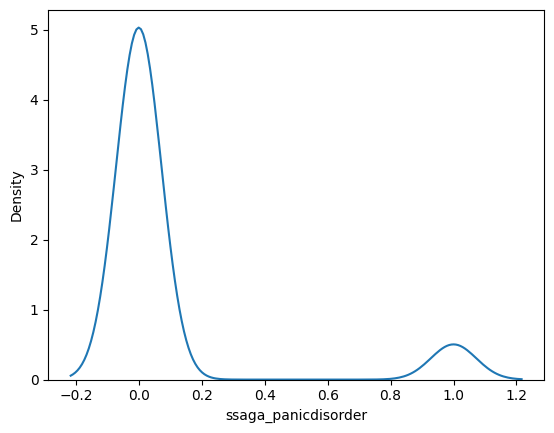

In [59]:
sns.kdeplot(hcp_sbr_df.query("TR == 3600 and network == 'Noise'")["ssaga_panicdisorder"], bw_method=0.25)

In [60]:
clin_vars = ['age_in_yrs',
 'handedness',
 'ssaga_employ',
 'ssaga_income',
 'ssaga_educ',
 'ssaga_inschool',
 'ssaga_rlshp',
 'ssaga_moborn',
 'height',
 'weight',
 'bmi',
 'ssaga_bmicat',
 'ssaga_bmicatheaviest',
 'hematocrit_1',
 'hematocrit_2',
 'bpsystolic',
 'bpdiastolic',
 'thyroidhormone',
 'hba1c',
 'famhist_moth_dep',
 'famhist_fath_dep',
 'famhist_moth_bp',
 'famhist_fath_bp',
 'famhist_moth_anx',
 'famhist_fath_anx',
 'famhist_moth_drgalc',
 'famhist_fath_drgalc',
 'asr_anxd_raw',
 'asr_anxd_pct',
 'asr_witd_raw',
 'asr_witd_t',
 'asr_soma_raw',
 'asr_soma_t',
 'asr_thot_raw',
 'asr_thot_t',
 'asr_attn_raw',
 'asr_attn_t',
 'asr_aggr_raw',
 'asr_aggr_t',
 'asr_rule_raw',
 'asr_rule_t',
 'asr_intr_raw',
 'asr_intr_t',
 'asr_oth_raw',
 'asr_crit_raw',
 'asr_intn_raw',
 'asr_intn_t',
 'asr_extn_raw',
 'asr_extn_t',
 'asr_tao_sum',
 'asr_totp_raw',
 'asr_totp_t',
 'dsm_depr_raw',
 'dsm_depr_t',
 'dsm_anxi_raw',
 'dsm_anxi_t',
 'dsm_somp_raw',
 'dsm_somp_t',
 'dsm_avoid_raw',
 'dsm_avoid_t',
 'dsm_adh_raw',
 'dsm_adh_t',
 'dsm_inat_raw',
 'dsm_hype_raw',
 'dsm_antis_raw',
 'dsm_antis_t',
 'ssaga_childhoodconduct',
 'ssaga_panicdisorder',
 'ssaga_agoraphobia',
 'ssaga_depressive_ep',
 'ssaga_depressive_sx',
 'total_drinks_7days',
 'num_days_drank_7days',
 'avg_weekday_drinks_7days',
 'avg_weekend_drinks_7days',
 'ssaga_alc_d4_dp_sx',
 'ssaga_alc_d4_ab_dx',
 'ssaga_alc_d4_ab_sx',
 'ssaga_alc_d4_dp_dx',
 'ssaga_alc_12_drinks_per_day',
 'ssaga_alc_12_frq',
 'ssaga_alc_12_frq_5plus',
 'ssaga_alc_12_frq_drk',
 'ssaga_alc_12_max_drinks',
 'ssaga_alc_age_1st_use',
 'ssaga_alc_hvy_drinks_per_day',
 'ssaga_alc_hvy_frq',
 'ssaga_alc_hvy_frq_5plus',
 'ssaga_alc_hvy_frq_drk',
 'ssaga_alc_hvy_max_drinks',
 'total_any_tobacco_7days',
 'times_used_any_tobacco_today',
 'num_days_used_any_tobacco_7days',
 'avg_weekday_any_tobacco_7days',
 'avg_weekend_any_tobacco_7days',
 'ssaga_ftnd_score',
 'ssaga_hsi_score',
 'ssaga_tb_age_1st_cig',
 'ssaga_tb_dsm_difficulty_quitting',
 'ssaga_tb_dsm_tolerance',
 'ssaga_tb_dsm_withdrawal',
 'ssaga_tb_hvy_cpd',
 'ssaga_tb_max_cigs',
 'ssaga_tb_reg_cpd',
 'ssaga_tb_smoking_history',
 'ssaga_tb_still_smoking',
 'ssaga_tb_yrs_since_quit',
 'ssaga_tb_yrs_smoked',
 'ssaga_times_used_illicits',
 'ssaga_times_used_cocaine',
 'ssaga_times_used_hallucinogens',
 'ssaga_times_used_opiates',
 'ssaga_times_used_sedatives',
 'ssaga_times_used_stimulants',
 'ssaga_mj_use',
 'ssaga_mj_ab_dep',
 'ssaga_mj_age_1st_use',
 'ssaga_mj_times_used',
]

In [114]:
rs, ps = [], []
lbs = []
for var in clin_vars:
    full_cdf = hcp_sbr_df.pivot(index=['subject', var], columns="network", values='n_vertices').reset_index()
    full_cdf = full_cdf.dropna()
    r_i, p_i = scipy.stats.pearsonr(full_cdf[var].values.reshape(-1, 1), full_cdf[network_labels[:-1]], axis=0)
    rs.append(r_i)
    ps.append(p_i)
    lbs.append(f"{var} -- " + network_labels[:-1])

rs = np.hstack(rs)
ps = np.hstack(ps)
lbs = np.hstack(lbs)
qs = scipy.stats.false_discovery_control(ps)

si = np.where(ps < 0.05)[0]
print(len(si))

# for si_i in si:
#     print(lbs[si_i] + f"  |  r = {rs[si_i]:.2f}  | p = {ps[si_i]:.04f}")

122


<Axes: xlabel='n_vertices', ylabel='network'>

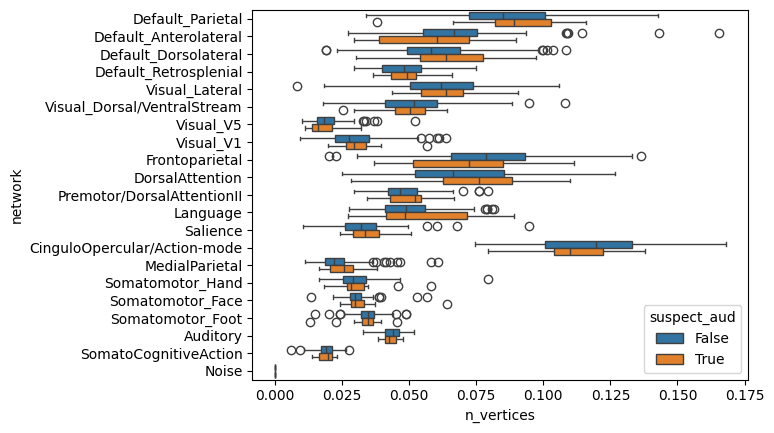

In [115]:
sns.boxplot(data=hcp_sbr_df, y="network", x="n_vertices", hue="suspect_aud")

In [116]:
hcp_sbr_df["path"] = hcp_sbr_df["suspect_aud"]
full_cdf = hcp_sbr_df.pivot(index=['subject', "path"], columns="network", values='n_vertices').reset_index()
full_cdf = full_cdf.dropna()

path_df = full_cdf.loc[full_cdf["path"]]
hc_df = full_cdf.loc[~full_cdf["path"]]

print("N pathology:", len(path_df))
print("N healthy:", len(hc_df))

t_s, p_s = scipy.stats.ttest_ind(path_df[network_labels[:-1]], hc_df[network_labels[:-1]])

q_s = scipy.stats.false_discovery_control(p_s)

sig_index = p_s < 0.05
print(network_labels[:-1][sig_index])
print(p_s[sig_index])

path_m_sizes = path_df[network_labels[:-1]].mean()
hc_m_sizes = hc_df[network_labels[:-1]].mean()
size_ratio = path_m_sizes / hc_m_sizes

print(size_ratio[sig_index])
for i, r, p, q in zip(size_ratio.index, size_ratio, p_s, q_s):
    print(f"{i} :: {r:.2f}, {p:0.3f}, {q:0.3f}")

N pathology: 15
N healthy: 162
[]
[]
Series([], dtype: float64)
Default_Parietal :: 1.05, 0.460, 0.809
Default_Anterolateral :: 0.86, 0.067, 0.594
Default_Dorsolateral :: 1.10, 0.225, 0.749
Default_Retrosplenial :: 1.00, 0.973, 0.987
Visual_Lateral :: 1.03, 0.707, 0.868
Visual_Dorsal/VentralStream :: 0.96, 0.607, 0.809
Visual_V5 :: 0.95, 0.519, 0.809
Visual_V1 :: 1.02, 0.850, 0.944
Frontoparietal :: 0.88, 0.106, 0.594
DorsalAttention :: 1.05, 0.540, 0.809
Premotor/DorsalAttentionII :: 1.04, 0.407, 0.809
Language :: 1.11, 0.106, 0.594
Salience :: 1.06, 0.418, 0.809
CinguloOpercular/Action-mode :: 0.94, 0.216, 0.749
MedialParietal :: 1.09, 0.262, 0.749
Somatomotor_Hand :: 1.02, 0.738, 0.868
Somatomotor_Face :: 1.07, 0.119, 0.594
Somatomotor_Foot :: 0.97, 0.466, 0.809
Auditory :: 0.99, 0.596, 0.809
SomatoCognitiveAction :: 1.00, 0.987, 0.987


In [117]:
twin_df = [g for g in hcp_sbr_df.groupby("family_id")]

In [118]:
sibling_db = {}
for fid in hcp_sbr_df["family_id"].unique():
    sibling_set = hcp_sbr_df.query(f"family_id == '{fid}'")["subject"].unique().tolist()
    if len(sibling_set) == 2:
        sibling_db[fid] = sibling_set
sibling_pairs = list(sibling_db.values())

In [119]:
sibling_only_df = [(hcp_sbr_df.query(f"subject == '{s1_id}'"), hcp_sbr_df.query(f"subject == '{s2_id}'")) for s1_id, s2_id in sibling_pairs]
MZ_only_df = [(d1, d2) for d1, d2 in sibling_only_df if d1["zygositysr"].iloc[0] == "MZ"]
NotMZ_only_df = [(d1, d2) for d1, d2 in sibling_only_df if d1["zygositysr"].iloc[0] != "MZ"]

In [120]:
delta_vars = ['age_in_yrs', 'asr_anxd_raw', 'asr_witd_t', 'asr_soma_t', 'asr_thot_t', 'asr_attn_t', 'asr_aggr_t',
              'asr_rule_t', 'asr_intr_t', 'asr_oth_raw', 'asr_crit_raw', 'asr_intn_t', 'asr_extn_t', 'asr_tao_sum',
              'asr_totp_t', 'dsm_depr_t', 'dsm_anxi_t', 'dsm_somp_t', 'dsm_avoid_t', 'dsm_adh_t', 'dsm_inat_raw',
              'dsm_hype_raw', 'dsm_antis_raw', 'dsm_antis_t', 'ssaga_childhoodconduct', 'ssaga_panicdisorder',
              'ssaga_agoraphobia', 'ssaga_depressive_ep', 'ssaga_depressive_sx', 'total_drinks_7days', "suspect_aud"
]

In [121]:

deltas_df = {var: [] for var in delta_vars + network_labels.tolist()}
for d1, d2 in sibling_only_df:
    d1 = d1.reset_index(drop=True)
    d2 = d2.reset_index(drop=True)
    for var in delta_vars:
        deltas_df[var].append(d1[var].iloc[0] * 1 - d2[var].iloc[0] * 1)


    # for net in network_labels[:-1]:
    for net, v in zip(network_labels, d1["n_vertices"] - d2["n_vertices"]):
        deltas_df[net].append(v)

deltas_df = {var: np.array(v) for var, v in deltas_df.items()}
deltas_df = pd.DataFrame(deltas_df)

In [122]:
vars_interest = delta_vars
# vars_interest = [ 'dsm_adh_t', 'dsm_inat_raw', 'dsm_hype_raw']

p_s_t = []
for var in vars_interest:
    value = deltas_df[var].values.reshape(-1, 1)
    value_sign = 1 - 2 * (value < 0)
    value_class = value * value_sign > 5
    
    signed_delta_df = deltas_df[[var] + network_labels.tolist()] * value_sign
    
    r_s, p_s = [], []
    for net in network_labels[:-1]:
        small_df = signed_delta_df[[var, net]].dropna()
        r, p = scipy.stats.pearsonr(small_df[var], small_df[net])
        r_s.append(r), p_s.append(p)
    
    r_s, p_s = np.array(r_s), np.array(p_s)
    p_s_t.append(p_s)
    q_s = scipy.stats.false_discovery_control(p_s)
    
    sig_index = q_s < 0.05
    if np.sum(sig_index):
        print(var, "::")
        print(network_labels[:-1][sig_index])
        print(r_s[sig_index], p_s[sig_index], q_s[sig_index])
        print()

asr_intn_t ::
['Default_Dorsolateral']
[0.35275728] [0.00099794] [0.01995873]

dsm_depr_t ::
['Default_Dorsolateral' 'Frontoparietal']
[ 0.3232049  -0.31534889] [0.0027108  0.00347951] [0.03479509 0.03479509]

dsm_adh_t ::
['Default_Dorsolateral']
[0.35295522] [0.00099095] [0.01981904]

dsm_hype_raw ::
['Default_Dorsolateral' 'Frontoparietal']
[ 0.32662147 -0.36760905] [0.00242691 0.00058173] [0.02426908 0.01163457]



# Twin Analysis

In [123]:
twin_df = [g for g in hcp_sbr_df.groupby("family_id")]

In [124]:
subject_pair_list = np.array([(s1, s2) for i, s1 in enumerate(subjects) for s2 in subjects[:i] if s1 != s2])
subject_pair_id_list = np.array([(s1, s2) for s1, _ in enumerate(subjects) for s2, _ in enumerate(subjects[:s1]) if s1 != s2])
subject_pair_dfs = [hcp_sbr_df[hcp_sbr_df["subject"].isin(pair)] for pair in subject_pair_list]
twin_labels = np.array(["Unrelated" if len(df["family_id"].unique()) == 2 else df["zygositysr"].iloc[0] for df in subject_pair_dfs])
twin_only_index = ~np.isin(twin_labels, ["Unrelated", "NotTwin"])
# twin_labels = np.array(["unrelated" if len(df["mother_id"].unique()) == 2 else "twin" for df in subject_pair_dfs])

In [128]:
# hcp_sbr_df["sex"] = hcp_sbr_df["menstrual_agebegan"].isna() * 1
# var_labels = np.array(["Diff Sex" if len(df["sex"].unique()) == 2 else df["sex"].iloc[0] for df in subject_pair_dfs])

In [129]:
diff_s = []
dice_s = []
for df, pair in zip(tqdm(subject_pair_dfs), subject_pair_list):
    df = df.sort_values("network")
    sizes_1 = df.loc[df["subject"] == pair[0]]["n_vertices"].values
    sizes_2 = df.loc[df["subject"] == pair[1]]["n_vertices"].values

    # diff_s.append(np.abs(sizes_1 - sizes_2))
    diff_s.append(np.abs(sizes_1 - sizes_2) / np.abs(sizes_1 + sizes_2) / 2)
diff_s = np.array(diff_s)

  0%|          | 0/15576 [00:00<?, ?it/s]

/var/folders/p0/zng86kys7t3578bm_dw7qjym00014h/T/ipykernel_3174/3884684648.py:9: RuntimeWarning: invalid value encountered in divide
  diff_s.append(np.abs(sizes_1 - sizes_2) / np.abs(sizes_1 + sizes_2) / 2)


In [130]:
vni_s_full = vni_s[tr_label_s == 3600]
pair_dice_s = np.array([dice_coef(vni_s_full[s1], vni_s_full[s2]) for s1, s2 in tqdm(subject_pair_id_list)])

  0%|          | 0/15576 [00:00<?, ?it/s]

In [131]:
net_pair_dice_s = np.array([[dice_coef(vni_s_full[s1] == net_i, vni_s_full[s2] == net_i)
                             for s1, s2 in tqdm(subject_pair_id_list, leave=False)]
                            for net_i in tqdm(np.arange(20))])

net_pair_dice_s = np.vstack([net_pair_dice_s, np.zeros(net_pair_dice_s.shape[1])]).T

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/15576 [00:00<?, ?it/s]

  0%|          | 0/15576 [00:00<?, ?it/s]

  0%|          | 0/15576 [00:00<?, ?it/s]

  0%|          | 0/15576 [00:00<?, ?it/s]

...

  0%|          | 0/15576 [00:00<?, ?it/s]

  0%|          | 0/15576 [00:00<?, ?it/s]

  0%|          | 0/15576 [00:00<?, ?it/s]

  0%|          | 0/15576 [00:00<?, ?it/s]

  0%|          | 0/15576 [00:00<?, ?it/s]

In [132]:
pair_dice_s = np.array([dice_coef(vni_s_full[s1], vni_s_full[s2]) for s1, s2 in tqdm(subject_pair_id_list)])

  0%|          | 0/15576 [00:00<?, ?it/s]

In [157]:
# pair_df = pd.DataFrame(net_pair_dice_s, columns=network_labels)
pair_df = pd.DataFrame(diff_s, columns=network_labels)
pair_df["twin"] = twin_labels
pair_df["mean_error"] = pair_df[network_labels[:-1]].mean(axis=1)
pair_df["network_dice"] = pair_dice_s
# pair_df["var"] = var_labels

order = np.sort(np.unique(twin_labels))
mpair_df = pd.melt(pair_df, id_vars=["twin"], value_vars=network_labels[:-1], var_name="network", value_name="size_delta")

<Axes: xlabel='size_delta', ylabel='network'>

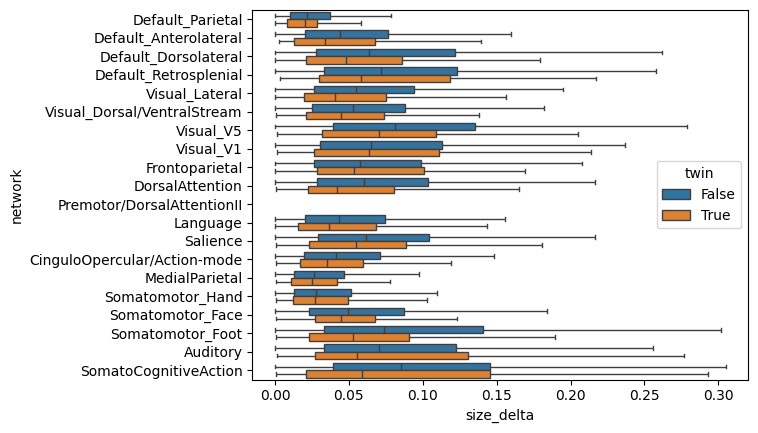

In [158]:
sns.boxplot(data=mpair_df, x="size_delta", y="network", hue=mpair_df["twin"] != "Unrelated", showfliers=False)

In [159]:
def ttest(var, index):
    """ """
    assert all(np.isin(index, [True, False]))
    
    ni = ~np.isnan(var)
    if isinstance(var, pd.core.frame.DataFrame):
        return scipy.stats.ttest_1samp(var.loc[index & ni], var.loc[~index & ni])

    return scipy.stats.ttest_ind(var[index & ni], var[~index & ni])

In [160]:
t_s, p_s = [], []
for net, net_dice_s in zip(network_labels, net_pair_dice_s.T[:-1]):
    t, p = ttest(net_dice_s, twin_labels != "Unrelated")
    t_s.append(t)
    p_s.append(p)

t_s = np.array(t_s)
p_s = np.array(p_s)
q_s = scipy.stats.false_discovery_control(p_s)

for net, t, p, q in zip(network_labels, t_s, p_s, q_s):
    if q > 0.05:
        print(net, p)
    if q < 0.05:
        print(f"*** {net} :: {t:.2f}  {p}   {q}")

*** Default_Parietal :: 7.23  4.980869248797592e-13   4.980869248797592e-12
*** Default_Anterolateral :: 6.84  7.943140588898722e-12   5.2954270592658144e-11
*** Default_Dorsolateral :: 5.93  3.180862746083575e-09   1.0602875820278583e-08
*** Default_Retrosplenial :: 5.69  1.3065906496085266e-08   3.7331161417386477e-08
*** Visual_Lateral :: 2.27  0.023517478717193535   0.02766762202022769
*** Visual_Dorsal/VentralStream :: 5.62  1.9387598085430382e-08   4.8468995213575953e-08
*** Visual_V5 :: 4.50  6.709488115616935e-06   1.1182480192694892e-05
*** Visual_V1 :: 2.57  0.010190343363095988   0.013587124484127983
*** Frontoparietal :: 5.43  5.859843556926357e-08   1.0654261012593375e-07
*** DorsalAttention :: 7.29  3.2737070727594413e-13   4.980869248797592e-12
*** Premotor/DorsalAttentionII :: 2.44  0.014815824452652981   0.018519780565816227
*** Language :: 5.51  3.725571844303901e-08   7.451143688607802e-08
*** Salience :: 5.52  3.3913352276347974e-08   7.451143688607802e-08
*** Cingu

(<Axes: >, <surfplot.plotting.Plot at 0x5bb614750>)

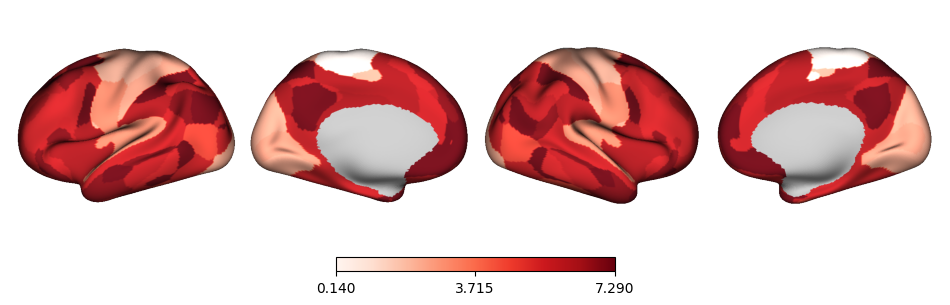

In [161]:
m, _ = scipy.stats.mode(vni_s, axis=0)
vertex_plot(t_s[m], example_cifti, cmap="Reds")

<Axes: xlabel='twin', ylabel='network_dice'>

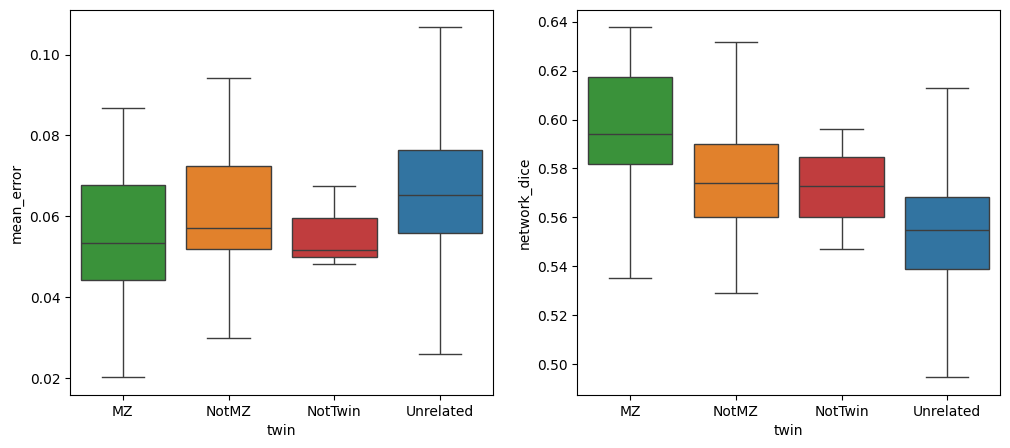

In [162]:
fig, (a0, a1) = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=pair_df, y="mean_error", x="twin", hue="twin", showfliers=False, ax=a0, order=order)
sns.boxplot(data=pair_df, y="network_dice", x="twin", hue="twin", showfliers=False, ax=a1, order=order)

In [163]:
print(ttest(pair_df["mean_error"], pair_df["twin"] == "Unrelated"))
print(ttest(pair_df["network_dice"], pair_df["twin"] == "Unrelated"))

TtestResult(statistic=np.float64(4.9394803140842045), pvalue=np.float64(7.914333119435032e-07), df=np.float64(15574.0))
TtestResult(statistic=np.float64(-12.459606315132516), pvalue=np.float64(1.8298142612819512e-35), df=np.float64(15574.0))


In [164]:
vpi_s = []
for parcel_path in tqdm(parcel_save_paths):
    parcel_vertex_i, parcel_assign = np.load(parcel_path)
    parcel_cortex_vi = parcel_vertex_i[parcel_vertex_i < 59_412]
    
    parcel_cortex_assign = np.full(59_412, fill_value=np.nan)
    parcel_cortex_assign[parcel_cortex_vi] = parcel_assign[parcel_cortex_vi]
    vpi_s.append(parcel_cortex_assign)

vpi_s = np.array(vpi_s)

  0%|          | 0/177 [00:00<?, ?it/s]

# weighted dice coef?

In [167]:
parcel_pairs = np.array(list(set(pair for pair in zip(s1, s2) if not np.isnan(np.sum(pair)) )))

In [168]:
def mod_dice_coef(s1, s2):
    """ """
    parcel_pairs = np.array(list(set(pair for pair in zip(s1, s2) if not np.isnan(np.sum(pair)) )))
    
    # weights = np.array([np.nansum(s1 == p1) + np.nansum(s1 == p2) for p1, p2 in parcel_pairs])
    # weights = weights / np.sum(weights)
    dc = np.array([dice_coef(s1 == p1, s2 == p2) for p1, p2 in parcel_pairs])

    # u1, u2 = parcel_pairs.T
    # c1 = s1 == u1.reshape(-1, 1)
    # c2 = s2 == u2.reshape(-1, 1)
    # dc = np.nansum(c1*c2, axis=1) / (np.nansum(c1, axis=1) + np.nansum(c2, axis=1))

    return np.mean(dc)


In [169]:
%timeit mod_dice_coef(s1, s2)

461 ms ± 1.84 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [170]:
import sklearn
def nan_safe_mutual_info(s1, s2):
    """ """
    ni = np.isnan(s1) | np.isnan(s2)
    return sklearn.metrics.mutual_info_score(s1[~ni], s2[~ni])

In [171]:
import torch
from torchmetrics.functional.clustering import mutual_info_score as tmutual_info

In [172]:
def torch_mutual_info(s1, s2, device="cpu"):
    """ """
    devp = dict(device=device, dtype=int)
    ni = np.isnan(s1) | np.isnan(s2)
    return tmutual_info(torch.tensor(s1[~ni], **devp), torch.tensor(s2[~ni], **devp)).cpu().numpy()

In [173]:
# parcel_mi_s = np.array([nan_safe_mutual_info(vpi_s[s1], vpi_s[s2]) for s1, s2 in tqdm(subject_pair_id_list)])
network_mi_s = np.array([torch_mutual_info(vni_s[s1], vni_s[s2]) for s1, s2 in tqdm(subject_pair_id_list)])
parcel_mi_s = np.array([torch_mutual_info(vpi_s[s1], vpi_s[s2]) for s1, s2 in tqdm(subject_pair_id_list)])
# parcel_dice_s = np.array([mod_dice_coef(vpi_s[s1], vpi_s[s2]) for s1, s2 in tqdm(subject_pair_id_list)])

  0%|          | 0/15576 [00:00<?, ?it/s]

  0%|          | 0/15576 [00:00<?, ?it/s]

In [174]:
pair_df["parcel_MI"] = parcel_mi_s
pair_df["network_MI"] = network_mi_s

<Axes: xlabel='twin', ylabel='network_MI'>

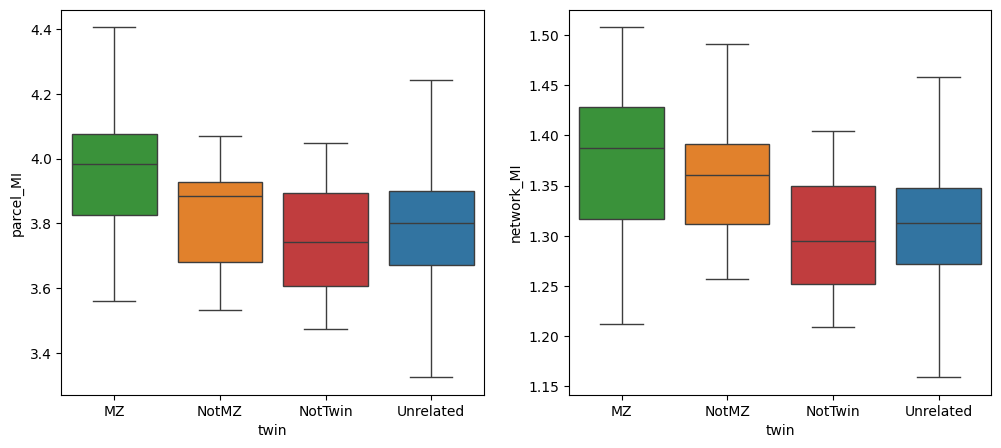

In [175]:
fig, (a0, a1) = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=pair_df, y="parcel_MI", x="twin", hue="twin", showfliers=False, ax=a0, order=order)
sns.boxplot(data=pair_df, y="network_MI", x="twin", hue="twin", showfliers=False, ax=a1, order=order)

# todo:
    [] further twin studies stuff:
        - [] where are more conserved regions?
            [] map of brain mutual info?
                [] sliding window of mutual info??
        - [] network areas that are different
        - [] parcel boundary probabilities

In [184]:
tw_pairs = subject_pair_id_list[twin_labels == "MZ"]
# tw_pairs = subject_pair_id_list[np.isin(twin_labels, ["NotMZ"])]
ur_pairs = subject_pair_id_list[twin_labels == "Unrelated"]

In [176]:
import nibabel as nib
import numpy as np

def compute_vertex_adjacency(surf_file):
    surf = nib.load(surf_file)
    vertices, faces = surf.darrays[0].data, surf.darrays[1].data

    adjacency = {i: set() for i in range(len(vertices))}
    for face in faces:
        for i, j in zip(face, np.roll(face, -1)):
            adjacency[i].add(j)
            adjacency[j].add(i)

    adjacency_list = [list(neighbors) for neighbors in adjacency.values()]
    return adjacency_list

def compute_combined_adjacency(left_surf_file, right_surf_file):
    # Process left hemisphere
    left_adjacency = compute_vertex_adjacency(left_surf_file)

    # Process right hemisphere
    right_adjacency = compute_vertex_adjacency(right_surf_file)

    # Offset right hemisphere indices to avoid overlap
    left_vertex_count = len(left_adjacency)
    right_adjacency_offset = [
        [neighbor + left_vertex_count for neighbor in neighbors]
        for neighbors in right_adjacency
    ]

    # Combine both hemispheres
    combined_adjacency = left_adjacency + right_adjacency_offset
    return combined_adjacency

# Example usage
# Replace 'left.surf.gii' and 'right.surf.gii' with your file paths

L_surf_gii = '/System/Volumes/Data/data/data1/atlases/HCP_S1200_Atlas/S1200.L.midthickness_MSMAll.32k_fs_LR.surf.gii'
R_surf_gii = '/System/Volumes/Data/data/data1/atlases/HCP_S1200_Atlas/S1200.R.midthickness_MSMAll.32k_fs_LR.surf.gii'
combined_adjacency_64k = compute_combined_adjacency(L_surf_gii, R_surf_gii)
left_adjacency = compute_vertex_adjacency(L_surf_gii)
right_adjacency = compute_vertex_adjacency(R_surf_gii)

combined_adjacency = [combined_adjacency_64k[i] for i in np.where(~medial_wall_mask_64k)[0].astype(int)]

In [177]:
non_medial_wall_64k_indices = np.where(~medial_wall_mask_64k)[0].astype(int)
combined_adjacency = [[n for n in neighbors if n in non_medial_wall_64k_indices]
                      for neighbors in combined_adjacency]

non_medial_wall_vertices = np.full(len(medial_wall_mask_64k), fill_value=np.nan, dtype=int)
non_medial_wall_vertices[~medial_wall_mask_64k] = np.arange(len(vni_s[0]))

combined_adjacency = [non_medial_wall_vertices[ca_i] for ca_i in combined_adjacency]

/Users/cole/miniconda3/envs/nct/lib/python3.11/site-packages/numpy/_core/numeric.py:362: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(a, fill_value, casting='unsafe')


In [178]:
len(np.hstack(combined_adjacency_64k)), len(np.hstack(combined_adjacency))

(389880, 355488)

In [179]:
def compute_borders(cortex_data, vertex_adjacency):
    # cortex_data: array of shape (59412,) with values from 1 to 600 (parcellation indices)
    # vertex_adjacency: adjacency list or matrix for the cortical mesh

    borders = np.zeros_like(cortex_data, dtype=bool)

    for vertex, neighbors in enumerate(vertex_adjacency):
        for neighbor in neighbors:
            if vertex < 59_412 and neighbor < 59_412:
                if cortex_data[vertex] != cortex_data[neighbor]:
                    borders[vertex] = True
                    break

    return borders

In [180]:
local_coms = [np.hstack([[i], neighbors]) for i, neighbors in enumerate(combined_adjacency)]

In [181]:
def neighbor_dice(v1, v2, pbar=False, leave=False):
    """ """
    dice_local_i = np.full(len(local_coms), fill_value=np.nan)
    iter_ = tqdm(local_coms, leave=leave) if pbar else local_coms
    for i, com_index in enumerate(iter_):
        dice_local_i[i] = dice_coef(v1[com_index], v2[com_index])

    return dice_local_i

(<Axes: >, <surfplot.plotting.Plot at 0x5c1eccf50>)

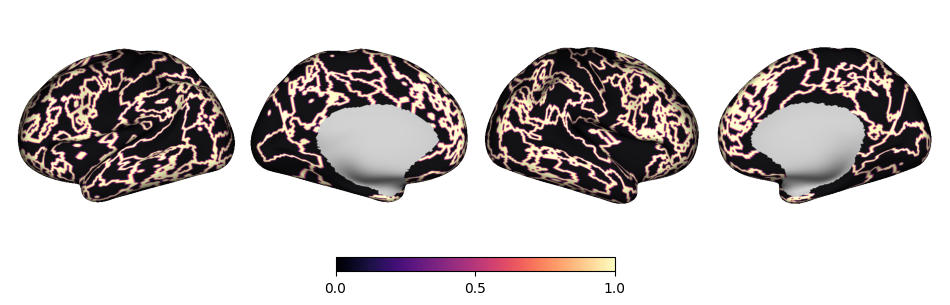

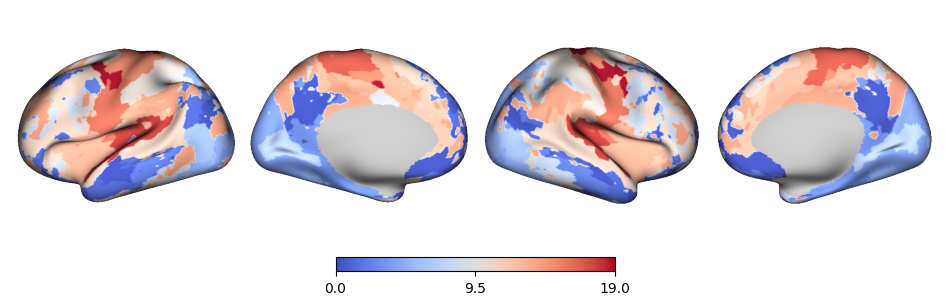

In [182]:
net_borders = compute_borders(vni_s[0], combined_adjacency) * 1
vertex_plot(net_borders, example_cifti, cmap="magma")
vertex_plot(vni_s[0], example_cifti)

  0%|          | 0/46 [00:00<?, ?it/s]

(<Axes: >, <surfplot.plotting.Plot at 0x5bf34e5d0>)

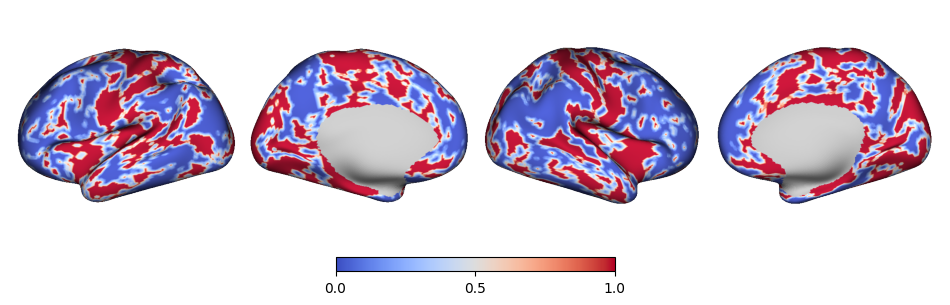

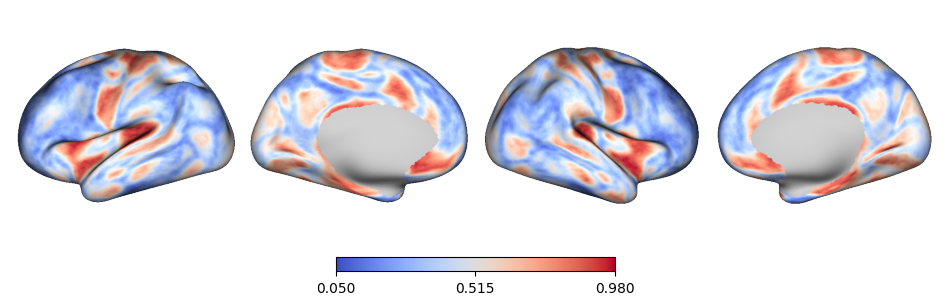

In [185]:
dice_local_i = neighbor_dice(vni_s[0], vni_s[1])
tw_dice_local = np.array([neighbor_dice(vni_s[p1], vni_s[p2]) for p1, p2 in tqdm(tw_pairs)])

vertex_plot(dice_local_i, example_cifti)
vertex_plot(tw_dice_local.mean(axis=0), example_cifti)

In [187]:
med_coms = [np.unique(np.hstack([local_coms[i] for i in com])) for com in local_coms]
big_coms = [np.unique(np.hstack([med_coms[i] for i in com])) for com in med_coms]

In [188]:
def local_parc_dice(v1, v2):
    g1 = v1 == scipy.stats.mode(v1, axis=1)[0].reshape(-1, 1)
    g2 = v2 == scipy.stats.mode(v2, axis=1)[0].reshape(-1, 1)

    card_sum = np.nansum(g1, axis=1) + np.nansum(g2, axis=1)
    
    return np.nansum(g1 * g2, axis=1) / (card_sum + 1 * (card_sum == 0))

In [190]:
vpi_moded = np.full(vpi_s.shape, fill_value=np.nan)
i
for j, com_subset in enumerate(tqdm(local_coms)):
    vpi_moded[i][j] = vpi_s[i][com_subset] == scipy.stats.mode(com_subset)[0]

  0%|          | 0/59412 [00:00<?, ?it/s]

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [211]:
n_sample = 100
sample_index = np.random.choice(np.arange(len(ur_pairs)), n_sample, replace=False)

In [212]:
com_grouping = local_coms
com_grouping = med_coms
# com_grouping = big_coms

max_com_subset_size = 500

com_sizes = np.array([len(z) for z in com_grouping])

t_s = np.full(len(com_sizes), fill_value=np.nan)
p_s = np.full(len(com_sizes), fill_value=np.nan)

for com_size in tqdm(np.sort(np.unique(com_sizes))):
    com_subset_index_all = np.where(com_sizes == com_size)[0]
    com_subset_all = np.array([com_grouping[i] for i in com_subset_index_all])

    for b in tqdm(range(int(np.ceil(len(com_subset_index_all) / max_com_subset_size))), leave=False):
        bl = slice(b * max_com_subset_size, (b + 1) * max_com_subset_size)

        com_subset_index = com_subset_index_all[bl]
        com_subset = com_subset_all[bl]

        t1 = np.array([(vni_s[s1][com_subset] == vni_s[s2][com_subset]).mean(axis=1) for s1, s2 in tw_pairs])
        t2 = np.array([(vni_s[s1][com_subset] == vni_s[s2][com_subset]).mean(axis=1) for s1, s2 in ur_pairs[sample_index]])

        # t1 = np.array([local_parc_dice(vpi_s[s1][com_subset], vpi_s[s2][com_subset]) for s1, s2 in tw_pairs])
        # t2 = np.array([local_parc_dice(vpi_s[s1][com_subset], vpi_s[s2][com_subset]) for s1, s2 in ur_pairs[sample_index]])

        t, p = scipy.stats.ttest_ind(t1, t2)
        
        t_s[com_subset_index] = t
        p_s[com_subset_index] = p

t, p = None, None
local_dice_t_s = np.array(t_s)
local_dice_p_s = np.array(p_s)
local_dice_q_s = np.full(local_dice_p_s.shape, fill_value=np.nan)
local_dice_q_s[~np.isnan(local_dice_p_s)]= scipy.stats.false_discovery_control(local_dice_p_s[~np.isnan(local_dice_p_s)])

  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/117 [00:00<?, ?it/s]

(<Axes: >, <surfplot.plotting.Plot at 0x7ed1d5310>)

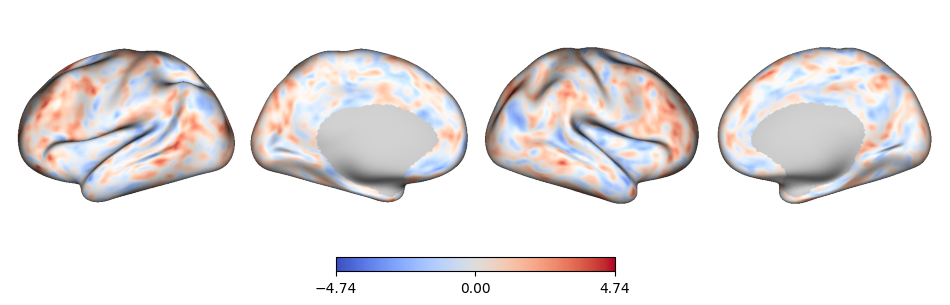

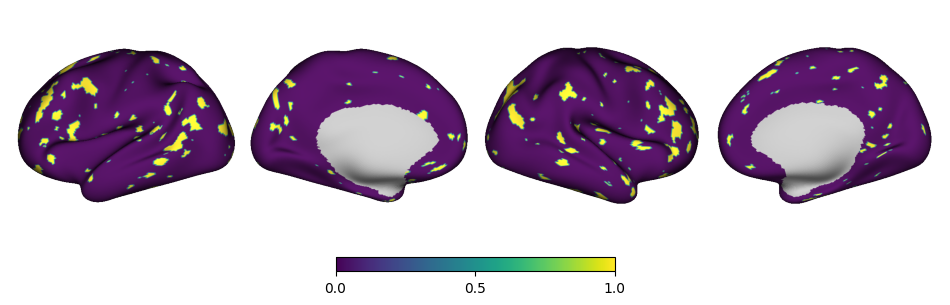

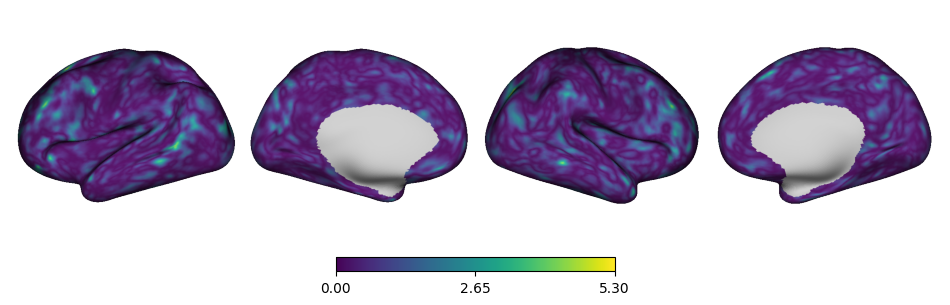

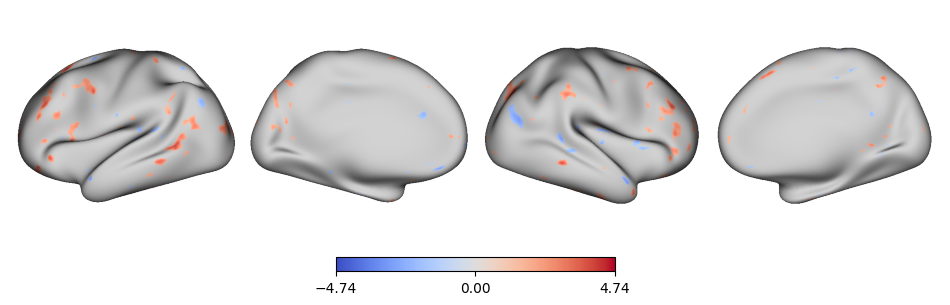

In [213]:
vertex_plot(np.clip(local_dice_t_s, -5, 5), example_cifti)

vertex_plot((local_dice_p_s < 0.05) * 1, example_cifti, cmap="viridis")
vertex_plot(-np.log10(local_dice_p_s), example_cifti, cmap="viridis")

masked_local_dice_t_s = local_dice_t_s.copy()
masked_local_dice_t_s[local_dice_p_s >= 0.05] = np.nan
vertex_plot(masked_local_dice_t_s, example_cifti)

In [ ]:
local_dice_t_s, local_dice_p_s = [], []
for i, com_index in enumerate(tqdm(local_coms)):
    
    t1 = np.array([dice_coef(vni_s[s1][com_index], vni_s[s2][com_index]) for s1, s2 in tw_pairs])
    t2 = np.array([dice_coef(vni_s[s1][com_index], vni_s[s2][com_index]) for s1, s2 in ur_pairs[sample_index]])

    t, p = scipy.stats.ttest_ind(t1, t2)

    local_dice_t_s.append(t)
    local_dice_p_s.append(p)
        
local_dice_p_s = np.array(local_dice_p_s)
local_dice_t_s = np.array(local_dice_t_s)
local_dice_q_s = np.full(local_dice_p_s.shape, fill_value=np.nan)
local_dice_q_s[~np.isnan(local_dice_p_s)]= scipy.stats.false_discovery_control(local_dice_p_s[~np.isnan(local_dice_p_s)])

  0%|          | 0/59412 [00:00<?, ?it/s]

(<Axes: >, <surfplot.plotting.Plot at 0x372f3b050>)

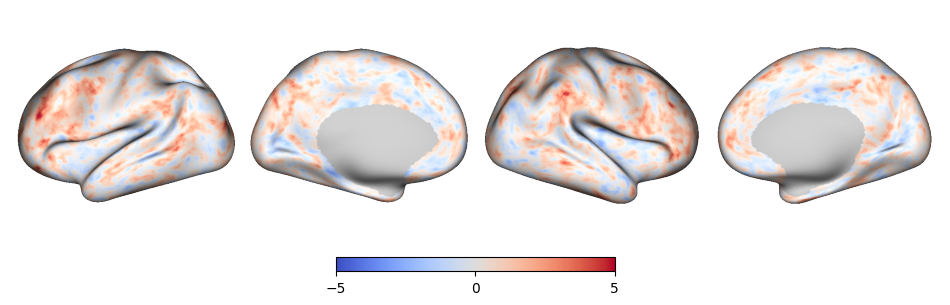

In [971]:
vertex_plot(np.clip(local_dice_t_s, -5, 5), example_cifti)

(<Axes: >, <surfplot.plotting.Plot at 0x67b9bf890>)

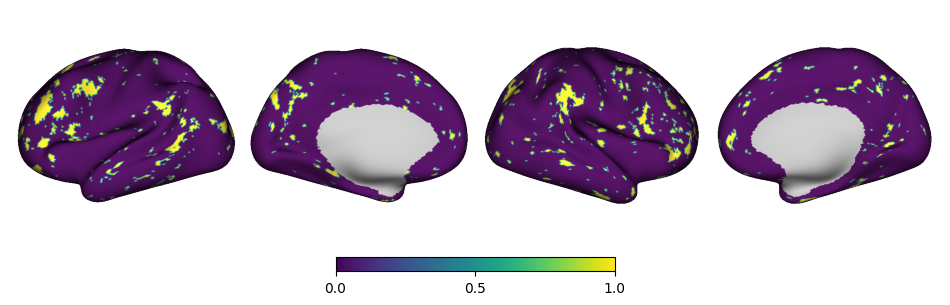

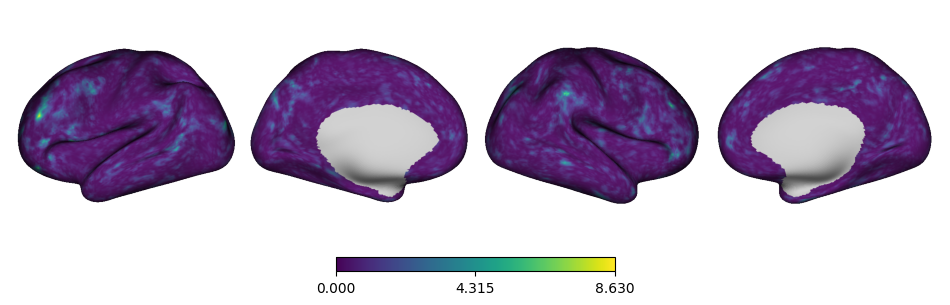

In [976]:
vertex_plot((p_s < 0.05) * 1, example_cifti, cmap="viridis")
vertex_plot(-np.log10(p_s), example_cifti, cmap="viridis")

(<Axes: >, <surfplot.plotting.Plot at 0x389090cd0>)

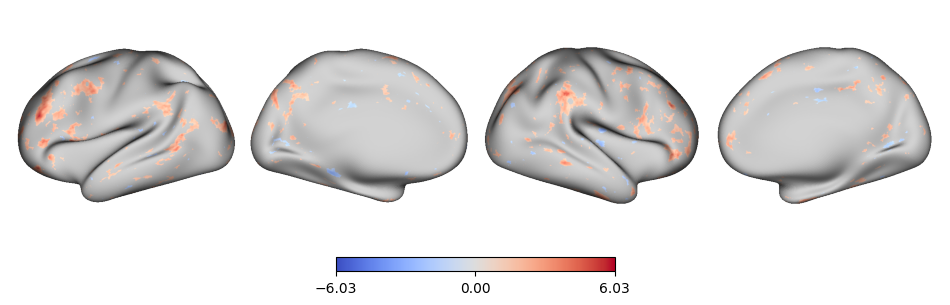

In [981]:
masked_local_dice_t_s = local_dice_t_s.copy()
masked_local_dice_t_s[p_s >= 0.15] = np.nan
vertex_plot(masked_local_dice_t_s, example_cifti)

In [ ]:
1 + 1

In [763]:
def calc_coassign_prob(assign_set, pairs):
    """ """
    coassign_prob = np.zeros_like(assign_set[0])
    for s1, s2 in tqdm(pairs):
        coassign_prob += assign_set[s1] == assign_set[s2]
    
    return coassign_prob / len(pairs)

In [765]:
from statsmodels.stats.proportion import proportions_ztest

z_s, p_s = [], []
b_size = 5_000
for b in tqdm(range(int(np.ceil(vni_s.shape[1] / b_size)))):

    b_slice = slice(b * b_size, (b + 1) * b_size)
    
    t1 = np.array([vni_s[s1][b_slice] == vni_s[s2][b_slice] for s1, s2 in tw_pairs])
    t2 = np.array([vni_s[s1][b_slice] == vni_s[s2][b_slice] for s1, s2 in ur_pairs])

    counts = np.array([np.sum(t1), np.sum(t2)])
    counts = np.vstack([np.sum(t1, axis=0), np.sum(t2, axis=0)])
    ns = np.array([len(t1), len(t2)])

    for c_i in counts.T:
        z_stat, p_value = proportions_ztest(c_i, ns)
        z_s.append(z_stat)
        p_s.append(p_value)
        
p_s = np.array(p_s)
z_s = np.array(z_s)
q_s = np.full(p_s.shape, fill_value=np.nan)
q_s[~np.isnan(p_s)]= scipy.stats.false_discovery_control(p_s[~np.isnan(p_s)])

  0%|          | 0/12 [00:00<?, ?it/s]

/Users/cole/miniconda3/envs/nct/lib/python3.11/site-packages/statsmodels/stats/weightstats.py:792: RuntimeWarning: invalid value encountered in scalar divide
  zstat = value / std


(<Axes: >, <surfplot.plotting.Plot at 0x3383b0d50>)

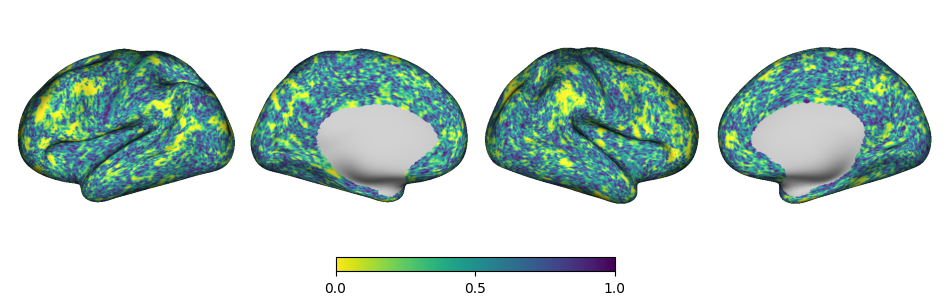

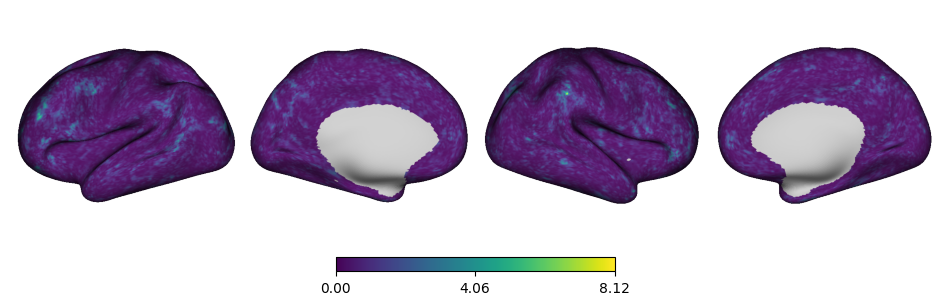

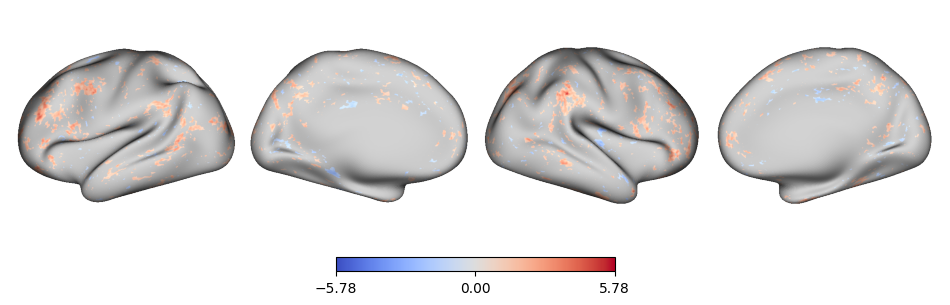

In [766]:
vertex_plot(p_s, example_cifti, cmap=plt.cm.viridis_r)
vertex_plot(-np.log10(p_s), example_cifti, cmap=plt.cm.viridis)

z_sn = z_s.copy()
z_sn[p_s >= 0.3] = np.nan
vertex_plot(z_sn, example_cifti, cmap=plt.cm.coolwarm)

In [91]:
unrelated_network_coassign_prob = calc_coassign_prob(vni_s, subject_pair_id_list[twin_labels == "Unrelated"])
MZ_network_coassign_prob = calc_coassign_prob(vni_s, subject_pair_id_list[twin_labels == "MZ"])

  0%|          | 0/15486 [00:00<?, ?it/s]

  0%|          | 0/46 [00:00<?, ?it/s]

(<Axes: >, <surfplot.plotting.Plot at 0x6a38904d0>)

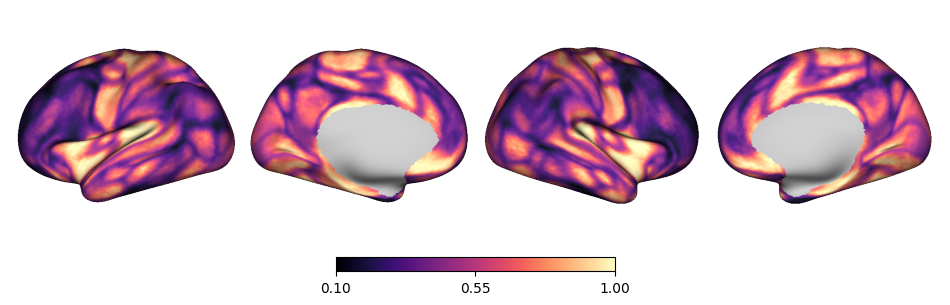

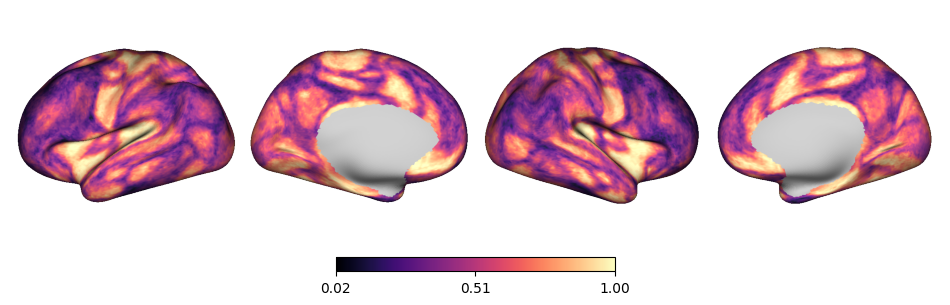

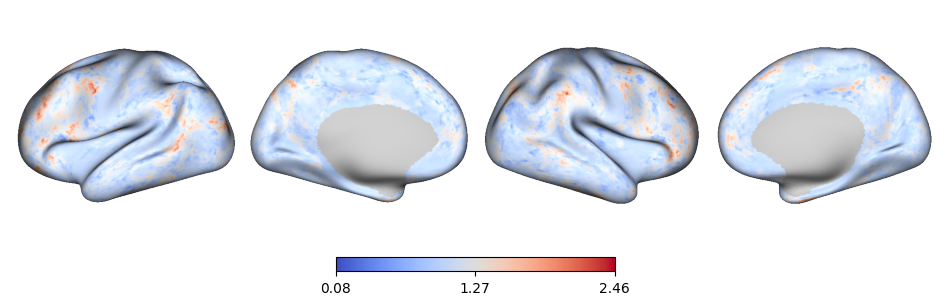

In [93]:
vertex_plot(unrelated_network_coassign_prob, example_cifti, cmap=plt.cm.magma)
vertex_plot(MZ_network_coassign_prob, example_cifti, cmap=plt.cm.magma)
# MZ_odds = MZ_network_coassign_prob / 
vertex_plot(MZ_network_coassign_prob / unrelated_network_coassign_prob, example_cifti, cmap=plt.cm.coolwarm)

In [94]:
s1, s2 = mz_pairs[0]
pmi = np.zeros_like(vpi_s[s1]) - 1

for parcel_i in tqdm(np.unique(vpi_s[s1])):
    if np.isnan(parcel_i):
        continue
    parcel_index = vpi_s[s1] == parcel_i
    p2_index = np.isin(vpi_s[s2], np.unique(vpi_s[s2][parcel_index]))
    # pmi[p2_index] = torch_mutual_info(parcel_index[p2_index], vpi_s[s2][p2_index])
    pmi[p2_index] = torch_mutual_info(parcel_index, vpi_s[s2]) #/ np.sqrt(np.nansum(parcel_index))

NameError: name 'mz_pairs' is not defined

In [95]:
vertex_plot(pmi, example_cifti, cmap=plt.cm.Spectral)

NameError: name 'pmi' is not defined

In [96]:
parcel_i

NameError: name 'parcel_i' is not defined

In [97]:
mz_pairs = subject_pair_id_list[twin_labels == "MZ"]

In [98]:
window_size = 3
vpi_s.shape

i = 0

In [99]:
wz = []
for i in tqdm(range(int(np.ceil(vpi_s.shape[1] / window_size)))):
    w_index = slice(i * window_size, (i + 1) * window_size)
    window_mi = np.array([torch_mutual_info(vpi_s[s1][w_index], vpi_s[s2][w_index]) for s1, s2 in mz_pairs])
    wz.append([np.mean(window_mi)] * window_size)
wz = np.hstack(wz)[:vpi_s.shape[1]]

  0%|          | 0/19804 [00:00<?, ?it/s]

(<Axes: >, <surfplot.plotting.Plot at 0x3c7f98450>)

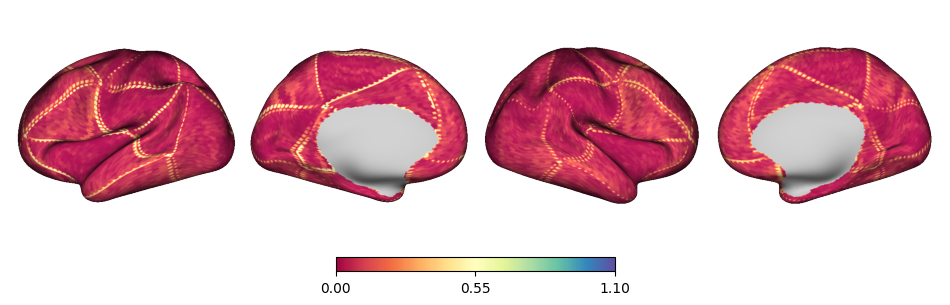

In [284]:
vertex_plot(wz, example_cifti, cmap=plt.cm.Spectral)


# Intra Parcel Connectivity Analysis

In [126]:
ex_index = 0

In [327]:
network_path = network_save_paths[ex_index]
FC_path = voxel_FC_save_paths[ex_index]
partition_path = parcel_save_paths[ex_index]

template_cifti = template_cifti

In [446]:
def load_FC_cortex(FC_path, template_cifti):
    """ """
    sc = scipy.sparse.load_npz(FC_path)
    cortex_index = pm.na.get_cortex_data(np.arange(sc.shape[0]).reshape(1, -1), template_cifti)[0]
    return sc[cortex_index][:, cortex_index]

def load_partition_labels(partition_path, template_cifti):
    """ """
    partition = np.load(partition_path)
    vertex_labels = pm.na.get_partition_cortex(partition, template_cifti)
    vertex_labels[np.isnan(vertex_labels)] = np.nanmax(vertex_labels) + 1
    remapped_vertex_labels = np.unique(vertex_labels, return_inverse=True)[1]
    return remapped_vertex_labels

def load_network_labels(network_path):
    return np.load(network_save_path)[0].astype(int)

def safe_mean(arr, **kwargs):
    # if arr.ndim == 1 and len(arr) == 0:
    #     return np.nan
    return np.mean(arr, **kwargs)


def calculate_mean_ROI_fc(sc_cortex, vertex_labels, only_nonzero=True, partial_nonzero=True):
    """ """
    unl = np.sort(np.unique(vertex_labels))
    if only_nonzero:
        mean_parcel_fc = np.array([safe_mean(sc_cortex[vertex_labels == label].data) for label in unl])
        mean_intraparcel_fc = np.array([safe_mean(sc_cortex[vertex_labels == label][:, vertex_labels == label].data) for label in unl])
    elif partial_nonzero:
        parcel_fc_z = np.vstack([safe_mean(sc_cortex[vertex_labels == label], axis=0).reshape(-1) for label in unl])
        mean_parcel_fc = np.array([safe_mean(parcel_fc[parcel_fc > 0]) for parcel_fc in parcel_fc_z])
        mean_intraparcel_fc = np.array([safe_mean(parcel_fc[(parcel_fc > 0) & (vertex_labels == label)])
                                        for label, parcel_fc in zip(unl, parcel_fc_z)])
    else:
        parcel_fc = np.vstack([safe_mean(sc_cortex[vertex_labels == label], axis=0).reshape(-1) for label in unl])
        mean_parcel_fc = np.array([safe_mean(parcel_fc) for parcel_fc in parcel_fc])
        mean_intraparcel_fc = np.array([safe_mean(parcel_fc[:, vertex_labels == label]) for label, parcel_fc in zip(unl, parcel_fc)])

    return mean_parcel_fc, mean_intraparcel_fc

def percent_clip(arr, lower=None, upper=None):
    v = arr[~np.isnan(arr)]
    return np.clip(arr, np.percentile(v, lower or 0), np.percentile(v, upper or 100))

def vertex_plot(values, template_cifti, ax=None, pclip=(None, None), **kwargs):
    """ """
    values = percent_clip(values, *pclip)
    values = CAP_tools.utils.cifti_map(None, values, template_cifti)
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 4))
    return sfm.surface_plot(values, ax=ax, **kwargs)

In [447]:
sc_cortex = load_FC_cortex(FC_path, template_cifti)
pni = load_partition_labels(partition_path, template_cifti)
vni = load_network_labels(network_path)

In [463]:
mean_parcel_fc_nz, mean_intraparcel_fc_nz = calculate_mean_ROI_fc(sc_cortex, pni, only_nonzero=True)
mean_network_fc_nz, mean_intranetwork_fc_nz = calculate_mean_ROI_fc(sc_cortex, vni, only_nonzero=True)

/Users/cole/miniconda3/envs/nct/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/cole/miniconda3/envs/nct/lib/python3.11/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


(<Axes: >, <surfplot.plotting.Plot at 0x41ddcb910>)

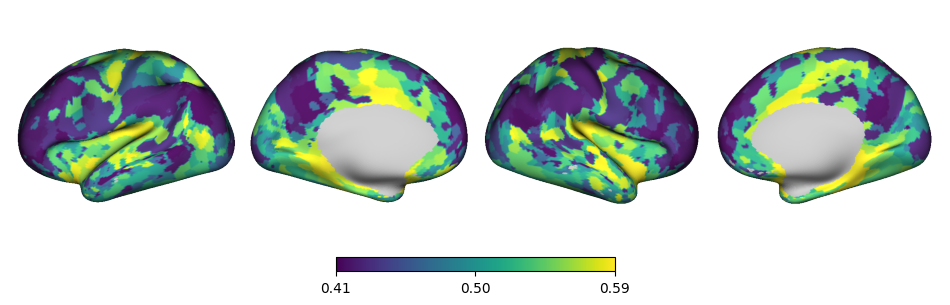

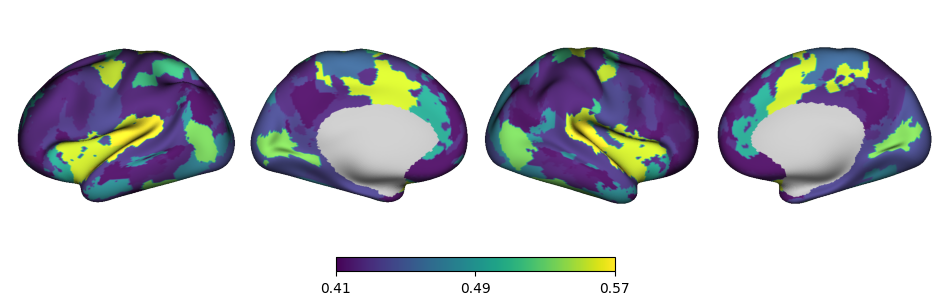

In [466]:
vertex_plot(mean_parcel_fc_nz[pni], template_cifti, cmap=plt.cm.viridis, pclip=(1, 95))
# vertex_plot(mean_intraparcel_fc_nz[pni], template_cifti, cmap=plt.cm.viridis, pclip=(1, 99))
vertex_plot(mean_network_fc_nz[vni], template_cifti, cmap=plt.cm.viridis, pclip=(1, 99))

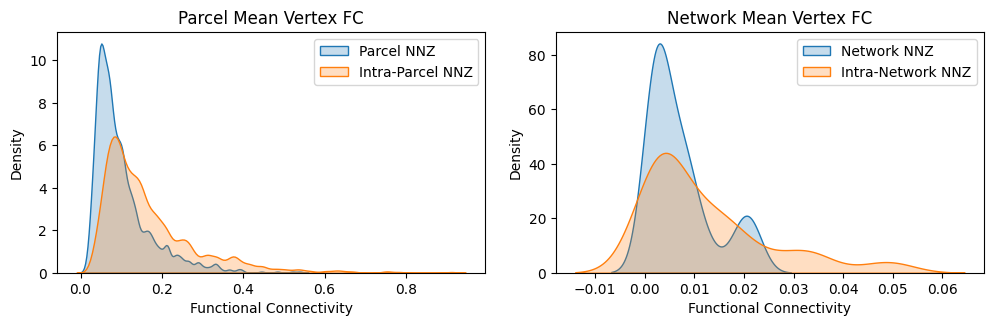

In [458]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
fig.tight_layout(w_pad=2)

for ax, label, (roi_means, intraroi_means) in zip(axes, ["Parcel", "Network"], [[mean_parcel_fc_nz, mean_intraparcel_fc_nz],
                                                   [mean_network_fc_nz, mean_intranetwork_fc_nz]]):

    bw = 0.1 if len(roi_means) > 500 else 0.4
    sns.kdeplot(roi_means, bw_method=bw, ax=ax, label=f"{label} NNZ", fill=True)
    sns.kdeplot(intraroi_means, bw_method=bw, ax=ax, label=f"Intra-{label} NNZ", fill=True)
    ax.set(title=f"{label} Mean Vertex FC", ylabel="Density", xlabel="Functional Connectivity")
    ax.legend()

[Text(0.5, 25.722222222222214, 'Intra Network Mean Vertex Functional Connectivity'),
 Text(619.9949494949494, 0.5, 'Network')]

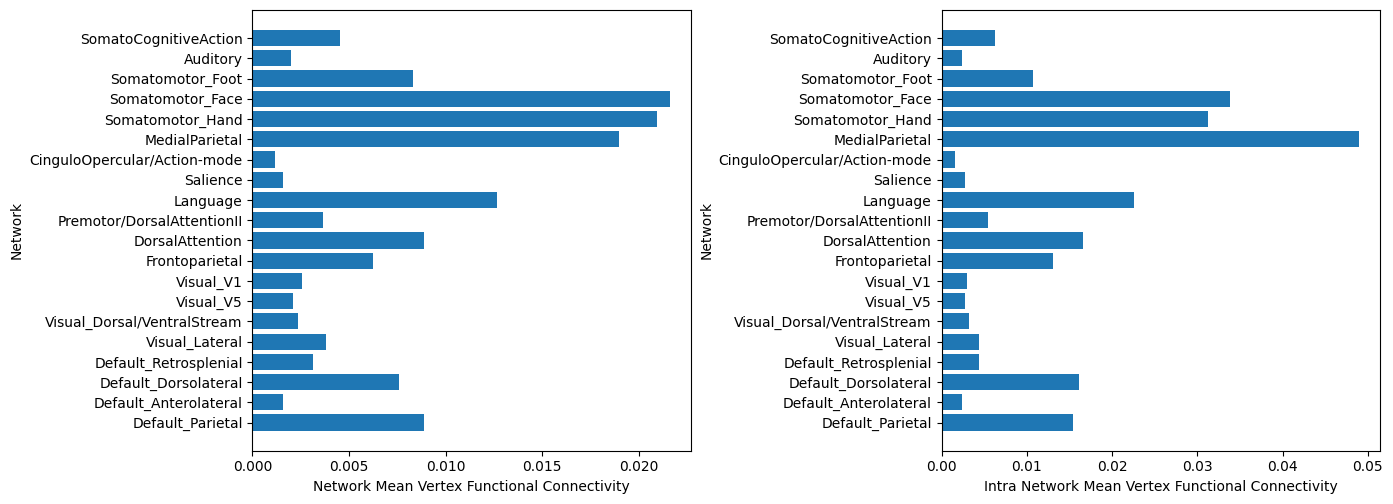

In [459]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.tight_layout(w_pad=15)
axes[0].barh(network_labels[:-1], mean_network_fc_nz)
axes[0].set(xlabel="Network Mean Vertex Functional Connectivity", ylabel="Network")

axes[1].barh(network_labels[:-1], mean_intranetwork_fc_nz)
axes[1].set(xlabel="Intra Network Mean Vertex Functional Connectivity", ylabel="Network")

<Axes: >

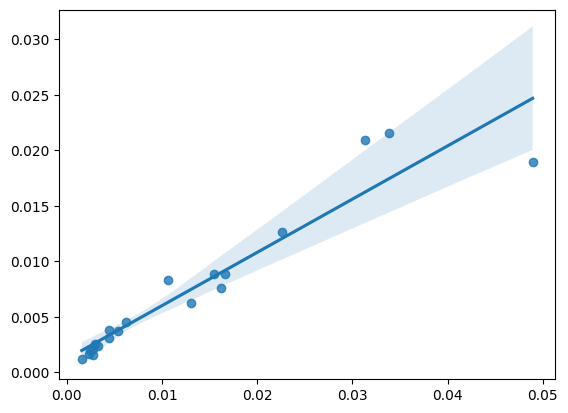

In [460]:
sns.regplot(x=mean_intranetwork_fc_nz, y=mean_network_fc_nz)

In [200]:
vni, vns = np.load(network_save_path)
vni = vni.astype("int")

sc = scipy.sparse.load_npz(voxel_FC_save_path)
cortex_index = pm.na.get_cortex_data(np.arange(sc.shape[0]).reshape(1, -1), template_cifti)[0]
sc_cortex = sc[cortex_index][:, cortex_index]

partition = np.load(partition_save_path)
vertex_labels = pm.na.get_partition_cortex(partition, template_cifti)
vertex_labels[np.isnan(vertex_labels)] = np.nanmax(vertex_labels) + 1
remapped_vertex_labels = np.unique(vertex_labels, return_inverse=True)[1]
pni = remapped_vertex_labels

cluster_labels = np.sort(np.unique(remapped_vertex_labels))
roi_index_set = remapped_vertex_labels.reshape(-1, 1) == cluster_labels

In [305]:
mean_parcel_fc_nz, mean_intraparcel_fc_nz = calculate_mean_ROI_fc(sc_cortex, remapped_vertex_labels, only_nonzero=True)
mean_network_fc_nz, mean_intranetwork_fc_nz = calculate_mean_ROI_fc(sc_cortex, vni, only_nonzero=True)

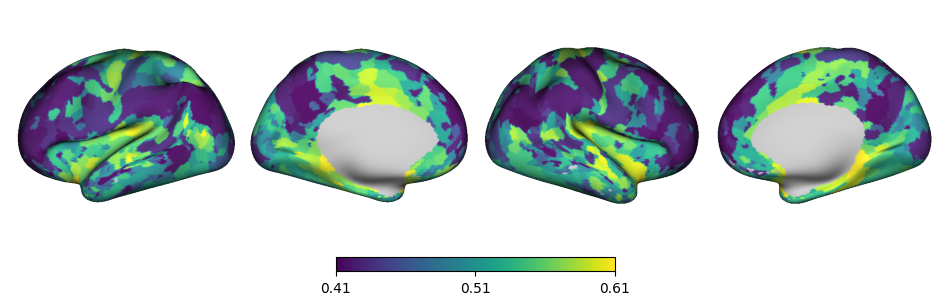

In [343]:
# z = mean_intraparcel_fcs[pni]
z = mean_intraparcel_fc_nz[pni]

# z = mean_parcel_fcs[pni]
z = mean_parcel_fc_nz[pni]

# z = mean_network_fc_s[vni]
# z = mean_network_fc_nz[vni]

# z = mean_intranetwork_fc_s[vni]
# z = mean_intranetwork_fc_nz[vni]

z = np.clip(z, np.percentile(z[~np.isnan(z)], 2), np.percentile(z[~np.isnan(z)], 99))

values = CAP_tools.utils.cifti_map(None, z, template_cifti)

fig, ax = plt.subplots(figsize=(12, 4))
ax, _ = sfm.surface_plot(values, cmap=plt.cm.viridis, ax=ax)

In [171]:
template_cifti = nb.load(cached_dtseries_paths[ex_index])

# full_vertex_data = pm.utils.load_voxel_data(dtseries_paths[ex_index])
# print(full_vertex_data.shape)
# vertex_data = pm.na.get_cortex_data(full_vertex_data, template_cifti)
# vertex_data = None

partition = np.load(parcel_save_paths[ex_index])
vertex_labels = pm.na.get_partition_cortex(partition, template_cifti)

In [172]:
vertex_labels[np.isnan(vertex_labels)] = np.nanmax(vertex_labels) + 1
remapped_vertex_labels = np.unique(vertex_labels, return_inverse=True)[1]

cluster_labels = np.sort(np.unique(remapped_vertex_labels))
roi_index_set = remapped_vertex_labels.reshape(-1, 1) == cluster_labels

FC, spatial, network_labels = pm.na.load_priors()
sp_corr = pm.utils.np_corr(spatial.T, roi_index_set * 1)

# roi_mean_signals = np.array([vertex_data[:, ri].mean(axis=1) for ri in roi_index_set.T]).T
# roi_mean_FCs = pm.utils.np_corr(vertex_data, roi_mean_signals)
# fc_corr = pm.utils.np_corr(FC.T, roi_mean_FCs)
# sp_fc_corr = sp_corr * fc_corr

sp_fc_index = np.argmax(sp_corr, axis=0)
# sp_fc_index = np.argmax(sp_fc_corr, axis=0)

vn = sp_fc_index[remapped_vertex_labels]
pn = remapped_vertex_labels
# roi_mean_signals = np.array([vertex_data[:, ri].mean(axis=1) for ri in roi_index_set.T]).T
# roi_mean_FCs = utils.np_corr(vertex_data, roi_mean_signals)

In [173]:
pn.shape

(59412,)

In [174]:
sc = scipy.sparse.load_npz(voxel_FC_save_paths[ex_index])

cortex_index = pm.na.get_cortex_data(np.arange(sc.shape[0]).reshape(1, -1), template_cifti)[0]
sc_cortex = sc[cortex_index][:, cortex_index]

In [175]:
sc, roi_index_set.shape

(<Compressed Sparse Row sparse matrix of dtype 'float32'
 	with 8332312 stored elements and shape (91282, 91282)>,
 (59412, 1071))

In [176]:
parcel_fc_nz = [np.nanmean(sc_cortex[roi_index_set[:, i]].data) for i in range(roi_index_set.shape[1])]

/var/folders/p0/zng86kys7t3578bm_dw7qjym00014h/T/ipykernel_58350/3375776889.py:1: RuntimeWarning: Mean of empty slice
  parcel_fc_nz = [np.nanmean(sc_cortex[roi_index_set[:, i]].data) for i in range(roi_index_set.shape[1])]


In [177]:
parcel_fc_s = np.vstack([np.mean(sc_cortex[roi_index_set[:, i]], axis=0).reshape(-1) for i in range(roi_index_set.shape[1])])
mean_parcel_fcs = np.array([np.mean(parcel_fc[parcel_fc > 0]) for parcel_fc in parcel_fc_s])
mean_intraparcel_fcs = np.array([np.mean(parcel_fc[(parcel_fc > 0) & (pn == i)]) for i, parcel_fc in enumerate(parcel_fc_s)])

mean_intranetwork_parcel_fcs = np.array([np.mean(parcel_fc[(parcel_fc > 0) & (vn == sp_fc_index[i])]) for i, parcel_fc in enumerate(parcel_fc_s)])

/Users/cole/miniconda3/envs/nct/lib/python3.11/site-packages/numpy/matrixlib/defmatrix.py:448: RuntimeWarning: Mean of empty slice.
  return N.ndarray.mean(self, axis, dtype, out, keepdims=True)._collapse(axis)
/Users/cole/miniconda3/envs/nct/lib/python3.11/site-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


In [178]:
np.nanmean(mean_intraparcel_fcs), np.nanmean(mean_intranetwork_parcel_fcs), np.nanmean(mean_parcel_fcs), len(sp_fc_index)

(np.float32(0.16633612), np.float32(0.12497975), np.float32(0.10196546), 1071)

In [179]:
nnz_row = np.array(np.sum(sc_cortex > 0, axis=0))

vertex_fc_s = np.array(sc_cortex.sum(axis=0)) / (nnz_row + (nnz_row == 0))

In [180]:
z = mean_intranetwork_parcel_fcs[vn]
z = mean_intraparcel_fcs[pn]
# z = mean_parcel_fcs[pn]
z = np.clip(z, np.percentile(z[~np.isnan(z)], 2), np.percentile(z[~np.isnan(z)], 99))

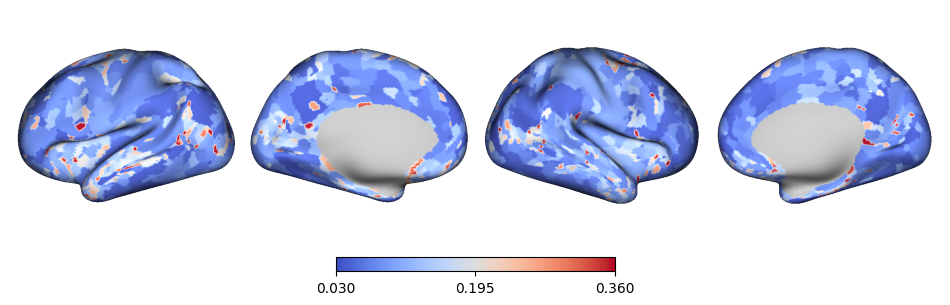

In [181]:
values = CAP_tools.utils.cifti_map(None, z, template_cifti)

fig, ax = plt.subplots(figsize=(12, 4))
ax, _ = sfm.surface_plot(values, cmap=plt.cm.coolwarm, ax=ax)

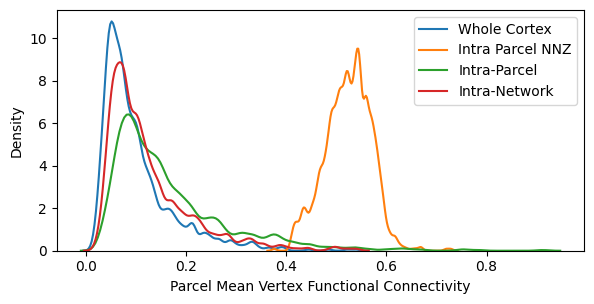

In [182]:
bw = 0.1
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
fig.tight_layout(w_pad=0)
sns.kdeplot(mean_parcel_fcs, bw_method=bw, ax=ax, label="Whole Cortex")
sns.kdeplot(parcel_fc_nz, bw_method=bw, ax=ax, label="Intra Parcel NNZ")
sns.kdeplot(mean_intraparcel_fcs, bw_method=bw, ax=ax, label="Intra-Parcel")
sns.kdeplot(mean_intranetwork_parcel_fcs, bw_method=bw, ax=ax, label="Intra-Network")
ax.set(xlabel="Parcel Mean Vertex Functional Connectivity", ylabel="Density")
ax.legend()

In [107]:
network_fc_s = np.array([np.mean(sc_cortex[vn == i], axis=0) for i in range(np.max(vn) + 1)]).squeeze()
mean_network_fc_s = np.array([np.mean(network_fc[network_fc > 0]) for network_fc in network_fc_s])

mean_intranetwork_fc_s = np.array([np.mean(network_fc[(network_fc > 0) & (vn == i)]) for i, network_fc in enumerate(network_fc_s)])

In [115]:
mean_network_fc_s.shape

(20,)

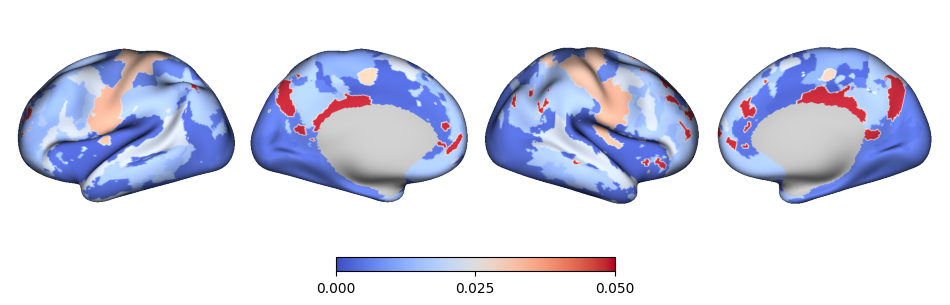

In [119]:
z = mean_network_fc_s[vn]
z = mean_intranetwork_fc_s[vn]

z = np.clip(z, np.percentile(z[~np.isnan(z)], 2), np.percentile(z[~np.isnan(z)], 99))
values = CAP_tools.utils.cifti_map(None, z, template_cifti)

fig, ax = plt.subplots(figsize=(12, 4))
ax, _ = sfm.surface_plot(values, cmap=plt.cm.coolwarm, ax=ax)

[Text(0.5, 25.722222222222214, 'Intra Network Mean Vertex Functional Connectivity'),
 Text(619.9949494949494, 0.5, 'Network')]

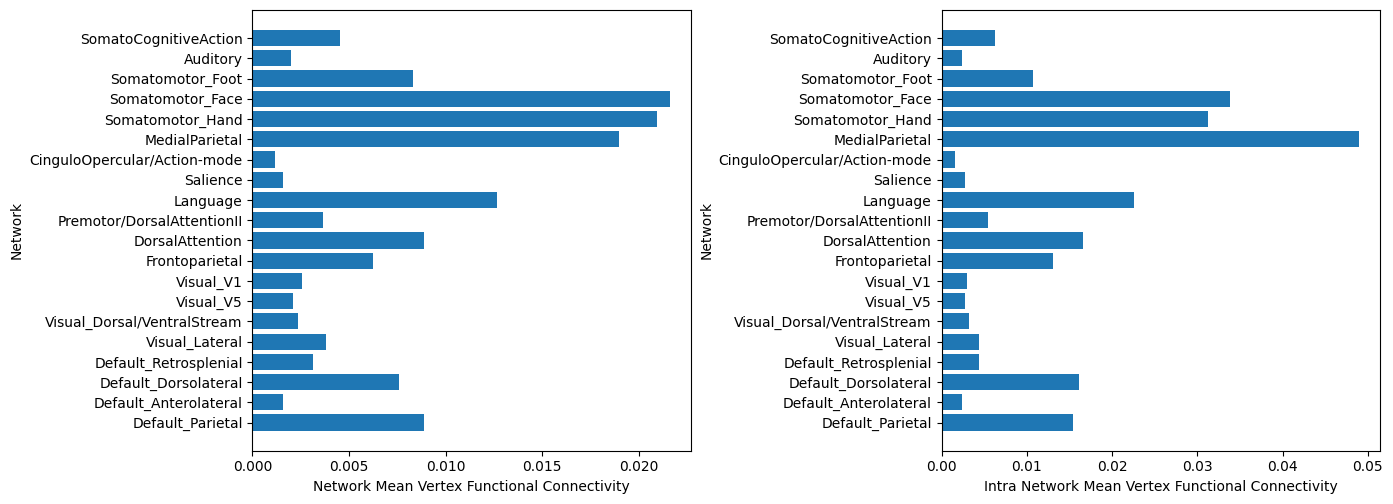

In [108]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.tight_layout(w_pad=15)
axes[0].barh(network_labels[:-1], mean_network_fc_s)
axes[0].set(xlabel="Network Mean Vertex Functional Connectivity", ylabel="Network")

axes[1].barh(network_labels[:-1], mean_intranetwork_fc_s)
axes[1].set(xlabel="Intra Network Mean Vertex Functional Connectivity", ylabel="Network")